# Default prediction — Mark 1: Predição de default em cartão de crédito

## Contexto

Este projeto tem como objetivo prever se um cliente de cartão de crédito vai dar default no pagamento da fatura no mês seguinte, a partir de variáveis demográficas e de histórico de pagamento.

Estou chamando este de "Mark 1" porque utilizo uma base de dados relativamente simples, em que não há valores ausentes e os dados estão consolidados em uma única tabela. A intenção é consolidar o pipeline ponta a ponta (EDA → pré-processamento → modelos → tuning → interpretação) num ambiente controlado, antes de seguir para datasets mais complexos como o Home Credit Default Risk.

## Os dados

A base é a **Default of Credit Card Clients** (UCI Machine Learning Repository), proveniente do artigo *"The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients"* (Yeh & Lien, 2009). Os dados foram coletados em Taiwan entre abril e setembro de 2005.

Link: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

São 30.000 observações e 25 colunas (mas o `ID` é só o índice, então temos efetivamente 24 features para modelagem):

**Identificador e target**
1. `ID`: índice do cliente (descartado antes da modelagem)
2. `default payment next month`: 1 se o cliente deu default no mês seguinte, 0 caso contrário. **Target**

**Demográficas**
3. `LIMIT_BAL`: limite de crédito concedido em NT$ (dólares de Taiwan). Inclui crédito individual e do suplementar familiar. Numérica contínua.
4. `SEX`: 1 = masculino, 2 = feminino
5. `EDUCATION`: 1 = pós-graduação, 2 = universidade, 3 = ensino médio, 4 = outros. Os dados também contêm os valores 0, 5 e 6, que não estão na documentação original.
6. `MARRIAGE`: 1 = casado, 2 = solteiro, 3 = outros. Também aparece o valor 0, não documentado.
7. `AGE`: idade em anos.

**Histórico de status de pagamento (`PAY_0` a `PAY_6`)**

São seis features representando o status de pagamento dos últimos seis meses, do mais recente para o mais antigo. Por uma quirk de nomenclatura do dataset, começa em `PAY_0` e pula para `PAY_2` — não existe `PAY_1`.

- `PAY_0`: setembro de 2005 (mais recente)
- `PAY_2`: agosto de 2005
- `PAY_3`: julho de 2005
- `PAY_4`: junho de 2005
- `PAY_5`: maio de 2005
- `PAY_6`: abril de 2005 (mais antigo)

A escala dos valores é:
- `-1` = pagou em dia
- `1` = atraso de 1 mês, `2` = atraso de 2 meses, ..., `8` = atraso de 8 meses
- `9` = atraso de 9 meses ou mais

Aparecem também os valores `-2` e `0`, não documentados originalmente. A interpretação aceita na literatura é: `-2` significa sem consumo no período (sem fatura para pagar) e `0` significa uso do crédito rotativo (pagou parcialmente o mínimo).

**Valor da fatura (`BILL_AMT1` a `BILL_AMT6`)**

Valor da fatura em NT$ nos mesmos seis meses, mesma ordem temporal. Numéricas contínuas. Podem ter valores negativos, indicando saldo credor (cliente pagou a mais ou teve estorno).

**Valor pago (`PAY_AMT1` a `PAY_AMT6`)**

Valor efetivamente pago pelo cliente em NT$ nos mesmos seis meses. Numéricas, sempre não-negativas. Zero significa que o cliente não pagou nada naquele mês.

## Hipóteses

Antes de explorar os dados, formulo as seguintes hipóteses baseadas em teoria econômica e prática de credit scoring:

1. **Indivíduos com limites de crédito maiores devem apresentar menor taxa de default** — correlação negativa esperada entre `LIMIT_BAL` e o target. O limite concedido reflete uma decisão de risco do banco baseada em informações disponíveis no momento da contratação.

2. **O status de pagamento mais recente (`PAY_0`) deve ser mais informativo que os mais antigos (`PAY_6`)** — além de o conteúdo informacional decair com o tempo, o status mais recente está temporalmente próximo ao target.

3. **A utilização do limite (razão entre `BILL_AMT` e `LIMIT_BAL`) deve ser mais informativa que o valor absoluto da fatura** — clientes com limites altos podem não usar a totalidade do limite, então o valor absoluto da fatura não captura adequadamente a pressão financeira.

4. **O comportamento de pagamento (frequência de pagamentos zero, pagamento parcial vs integral) deve ser mais informativo que o valor absoluto pago** — dois clientes pagando o mesmo valor podem ter perfis de risco muito diferentes a depender da relação desse valor com a fatura devida.

5. **Variáveis demográficas devem apresentar sinal preditivo fraco** — credit scoring moderno tende a privilegiar variáveis comportamentais sobre demográficas, e parte dessas variáveis tem uso restringido por regulação em diversas jurisdições.

Vou validar (ou refutar) cada uma dessas hipóteses ao longo do notebook, primeiro via EDA e depois via SHAP no modelo final.

---

## Decisão metodológica: correlação Spearman como padrão

Em todas as análises de correlação neste notebook, uso o coeficiente de **Spearman** em vez de Pearson, por duas razões:

1. **Robustez a outliers** — variáveis financeiras (`BILL_AMT`, `PAY_AMT`) têm caudas longas e valores extremos que distorcem Pearson
2. **Captura de relações monotônicas não-lineares** — em credit scoring, relações lineares são exceção, não regra

Spearman trabalha com ranks dos valores, o que naturalmente lida com esses dois problemas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_excel('default of credit card clients.xls', header=1)
print(df.shape)
df

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [3]:
df.drop(columns=['ID'], inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [5]:
colunas = df.columns

for coluna in colunas:
    print(f'valores contidos na coluna {coluna}: {df.select_dtypes(include='int64')[coluna].unique()}')

valores contidos na coluna LIMIT_BAL: [  20000  120000   90000   50000  500000  100000  140000  200000  260000
  630000   70000  250000  320000  360000  180000  130000  450000   60000
  230000  160000  280000   10000   40000  210000  150000  380000  310000
  400000   80000  290000  340000  300000   30000  240000  470000  480000
  350000  330000  110000  420000  170000  370000  270000  220000  190000
  510000  460000  440000  410000  490000  390000  580000  600000  620000
  610000  700000  670000  680000  430000  550000  540000 1000000  530000
  710000  560000  520000  750000  640000   16000  570000  590000  660000
  720000  327680  740000  800000  760000  690000  650000  780000  730000]
valores contidos na coluna SEX: [2 1]
valores contidos na coluna EDUCATION: [2 1 3 5 4 6 0]
valores contidos na coluna MARRIAGE: [1 2 3 0]
valores contidos na coluna AGE: [24 26 34 37 57 29 23 28 35 51 41 30 49 39 40 27 47 33 32 54 58 22 25 31
 46 42 43 45 56 44 53 38 63 36 52 48 55 60 50 75 61 73 59 21

## Observações iniciais sobre os dados

Algumas particularidades já visíveis na inspeção inicial e que vale ter em mente:

1. **`EDUCATION` tem valores 0, 5 e 6 não documentados** — a documentação original cobre apenas 1 a 4. Vou agrupar esses valores na categoria "outros" no pré-processamento.
2. **`MARRIAGE` tem valor 0 não documentado** — também será agrupado em "outros".
3. **`PAY_X` tem valores -2 e 0 não documentados** — usarei a interpretação aceita na literatura (sem consumo / pagamento parcial mínimo).
4. **`BILL_AMT` tem valores negativos** — saldo credor, comportamento normal em cartão de crédito.

---

# 1. Análise Exploratória dos Dados (EDA)

A EDA será conduzida em camadas, cada uma respondendo a uma pergunta específica:

1. **Sanidade dos dados** — tipos de variáveis, valores ausentes, ranges, duplicatas
2. **Análise da variável-alvo** — taxa de default e implicações para a modelagem
3. **Análise univariada condicionada ao target** — para cada feature, sua distribuição muda entre defaulters e não-defaulters?
4. **Relações bivariadas e multicolinearidade** — quais features carregam informação redundante?
5. **Validação inicial das hipóteses** — comparação dos achados da EDA com as hipóteses pré-formuladas

## 1.1 Análise da variável-alvo

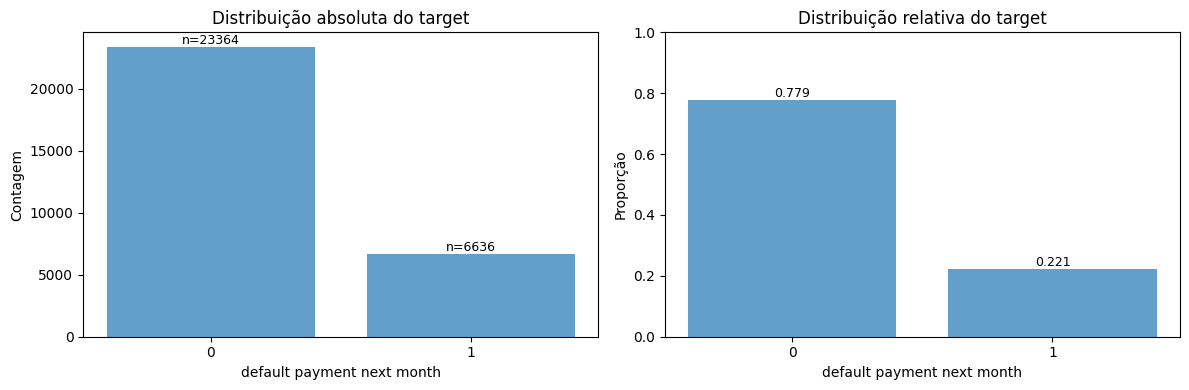

Taxa de default: 22.12%
Razão de desbalanceamento: 3.52:1


In [6]:
target = 'default payment next month'

counts = df[target].value_counts().sort_index()
proportions = df[target].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: contagem absoluta
axes[0].bar(counts.index.astype(str), counts.values, alpha=0.7)
axes[0].set_xlabel(target)
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição absoluta do target')
for idx, val in enumerate(counts.values):
    axes[0].text(idx, val + counts.max() * 0.01, f'n={val}', 
                 ha='center', fontsize=9)

# Gráfico 2: proporção
axes[1].bar(proportions.index.astype(str), proportions.values, alpha=0.7)
axes[1].set_xlabel(target)
axes[1].set_ylabel('Proporção')
axes[1].set_title('Distribuição relativa do target')
for idx, val in enumerate(proportions.values):
    axes[1].text(idx, val + 0.01, f'{val:.3f}', 
                 ha='center', fontsize=9)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Taxa de default: {proportions[1]:.2%}")
print(f"Razão de desbalanceamento: {counts[0] / counts[1]:.2f}:1")

**Achados sobre o target**:

- Taxa de default: **22,1%** (6.636 defaulters em 30.000)
- Razão de desbalanceamento: **~3,5:1** (3,5 não-defaulters para cada defaulter)

Esse desbalanceamento é **moderado** — não é o pesadelo do Home Credit (~11:1) nem das aplicações de fraude (centenas para 1), mas é suficiente para ditar três decisões de pipeline:

1. **Acurácia é uma métrica inadequada**. Um classificador trivial que prevê sempre "não-default" atingiria 78% de acurácia, sem valor prático. Vou usar **AUC-ROC, PR-AUC e KS** como métricas principais — todas robustas a desbalanceamento e padrão em credit scoring.

2. **Divisão treino/teste será estratificada** para preservar a proporção de classes em ambos os subconjuntos.

3. **Considerar técnicas de tratamento de desbalanceamento** (`class_weight='balanced'` na logística, `scale_pos_weight` no XGBoost). Para esse nível de desbalanceamento, geralmente esses ajustes simples bastam e técnicas mais agressivas como SMOTE não são necessárias.

## 1.2 Análise univariada condicionada ao target

A pergunta central aqui é: **a distribuição de cada feature muda dependendo se o cliente deu default?** Se mudar substancialmente, a feature carrega sinal preditivo. Se as duas distribuições forem praticamente idênticas, isoladamente a feature provavelmente não ajuda.

### 1.2.1 Variáveis numéricas — KDE sobreposta

Para variáveis contínuas, uso KDE (Kernel Density Estimation) sobreposta para defaulters (1) vs não-defaulters (0). O parâmetro `common_norm=False` é crucial: normaliza cada classe separadamente, evitando que a classe minoritária (defaulters, ~22%) apareça artificialmente "achatada" só por ser menor.

In [7]:
# Numéricas contínuas
num_cols = ['LIMIT_BAL', 'AGE'] + \
           [f'BILL_AMT{i}' for i in range(1, 7)] + \
           [f'PAY_AMT{i}' for i in range(1, 7)]

# Categóricas (incluindo ordinais que vamos tratar como categóricas no EDA)
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

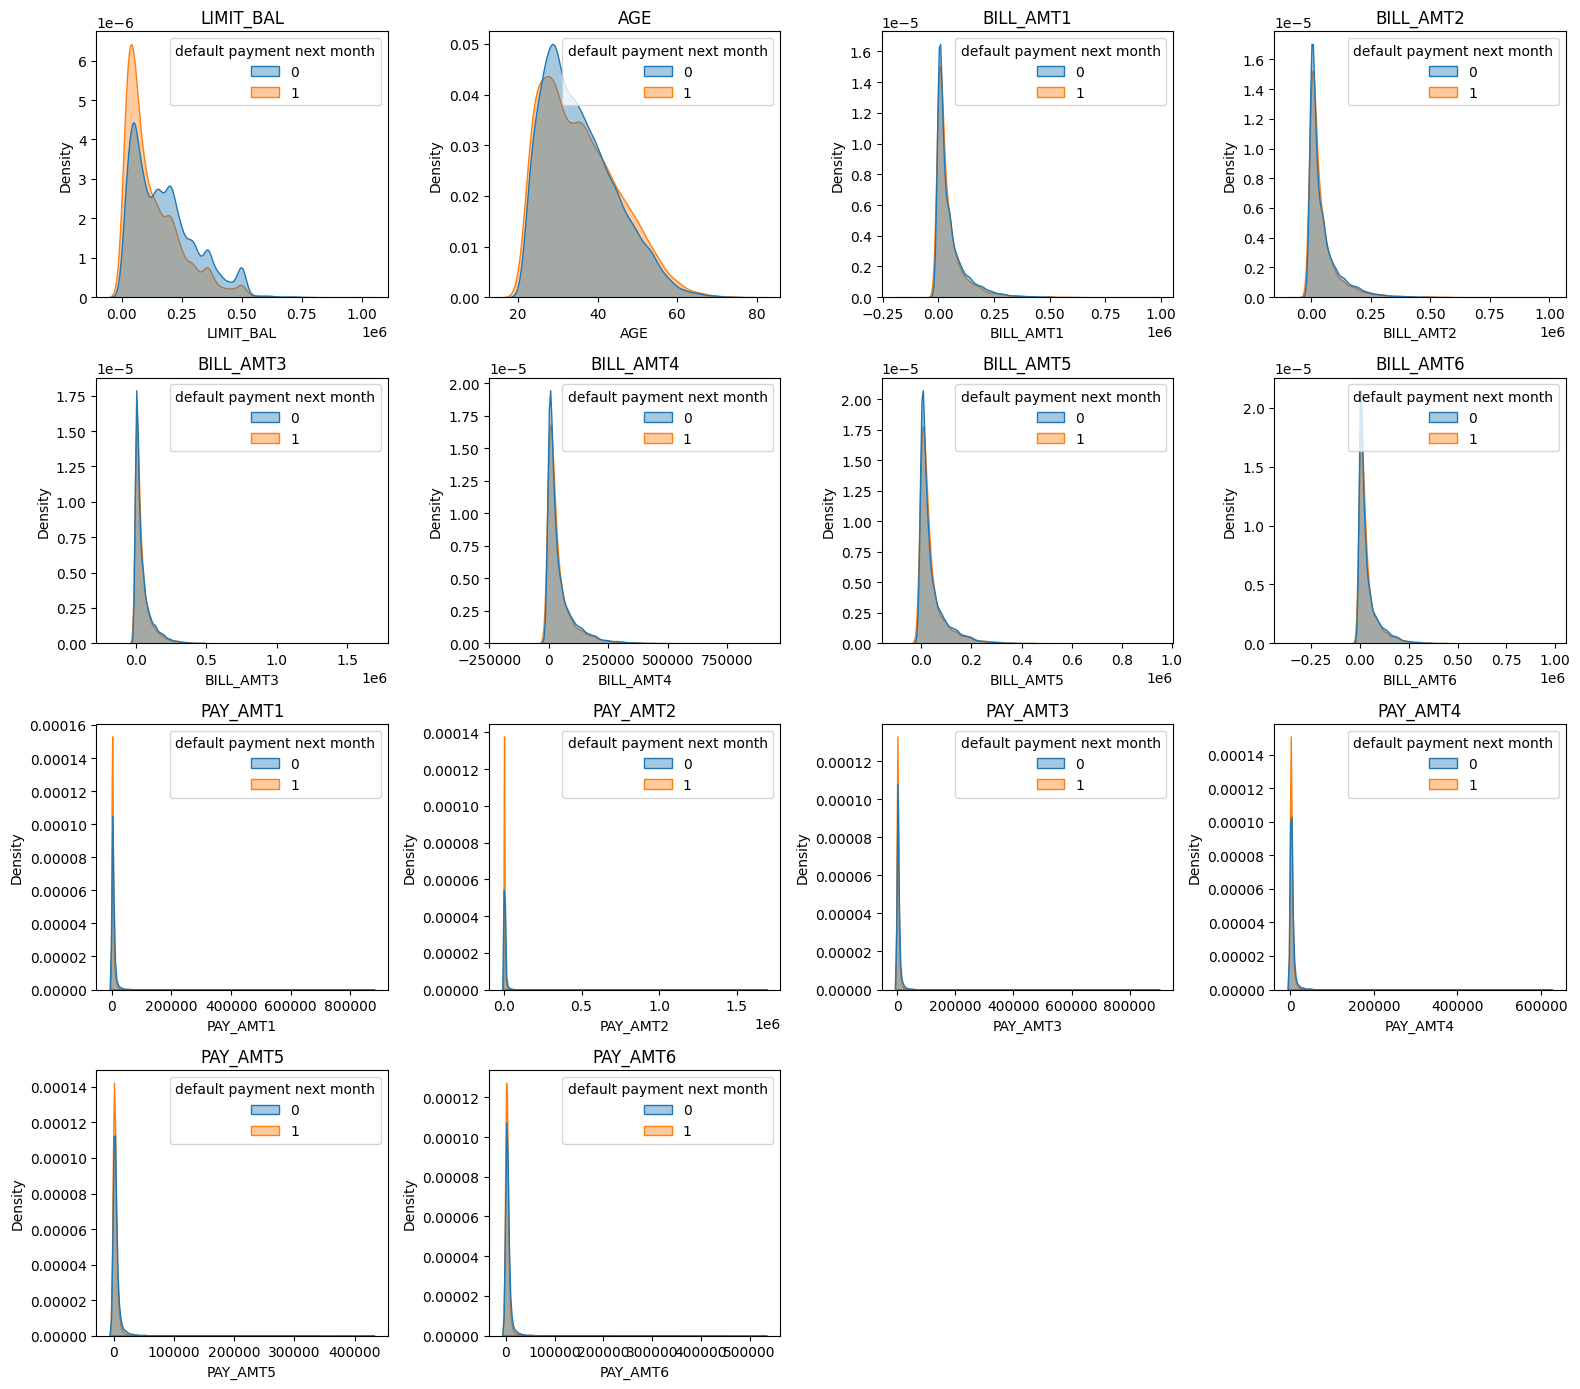

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue=target, 
                common_norm=False,  
                ax=axes[i], fill=True, alpha=0.4)
    axes[i].set_title(col)

# Esconde subplots não usados
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Leitura dos gráficos**:

- **`LIMIT_BAL`**: a curva laranja (defaulters) está deslocada para a esquerda, com pico mais alto e mais concentrado em valores baixos. A curva azul (não-defaulters) é mais espalhada, com massa apreciável em limites maiores. **Tradução**: clientes com limite mais baixo defaultam mais. Faz sentido econômico — o banco concede limites menores para perfis de risco. A feature tem sinal preditivo claro.

- **`AGE`**: as duas curvas estão praticamente sobrepostas. **Tradução**: idade isoladamente não separa bem as classes.

- **`BILL_AMT*` e `PAY_AMT*`**: os gráficos ficam praticamente impossíveis de ler em escala linear, pois a maioria dos valores está concentrada perto de zero e há outliers extremos esticando o eixo. Vou refazer em escala logarítmica.

### 1.2.2 PAY_AMT em escala logarítmica

In [9]:
# Log-transform para visualizar (mantém o sinal dos negativos em BILL_AMT)
df_log = df.copy()
for col in [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]:
    df_log[col] = np.sign(df_log[col]) * np.log1p(np.abs(df_log[col]))


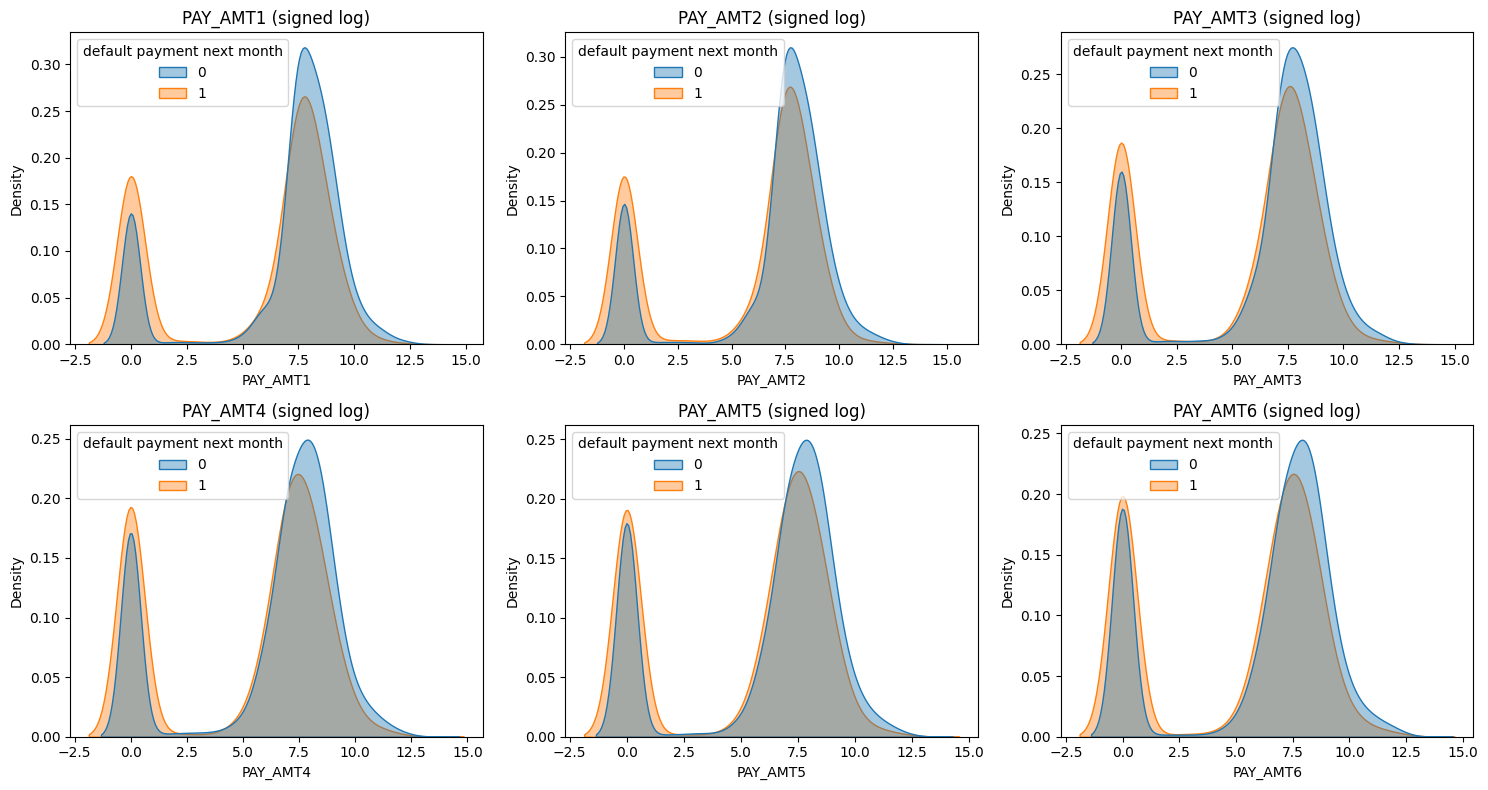

In [10]:
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pay_amt_cols):
    sns.kdeplot(data=df_log, x=col, hue=target,
                common_norm=False, ax=axes[i], fill=True, alpha=0.4)
    axes[i].set_title(f'{col} (signed log)')

plt.tight_layout()
plt.show()

**Leitura dos PAY_AMT em log**:

A estrutura mais importante aqui é a **bimodalidade** das duas distribuições, com dois picos:

- Pico em **x ≈ 0** (corresponde a `PAY_AMT = 0`): cliente que não pagou nada naquele mês
- Pico em **x ≈ 7,5 a 8** (corresponde a NT$ ~1.800-3.000): provavelmente o pagamento mínimo da fatura

Comparando proporções entre os picos:

- **Não-defaulters (azul)**: pico do "pagou algo" é claramente mais alto que o pico do "não pagou nada"
- **Defaulters (laranja)**: os dois picos têm altura **muito mais parecida** — em vários meses, o pico do zero quase iguala o pico do pagamento

**Tradução econômica**: defaulters têm probabilidade muito maior de zerar o pagamento em qualquer mês dado. E note que *quando* defaulters pagam, pagam um valor parecido com não-defaulters (os picos em ~7,5 estão na mesma posição). A diferença está na **frequência com que pagam zero**, não no quanto pagam quando pagam.

Esse achado é importante porque sugere uma feature engineering óbvia: **contagem de meses com `PAY_AMT = 0`** nos últimos 6 meses. Refina minha hipótese H4: o que importa não é o "comportamento de pagamento" genericamente, é especificamente a **frequência de pagamentos zero**.

### 1.2.3 BILL_AMT em escala logarítmica

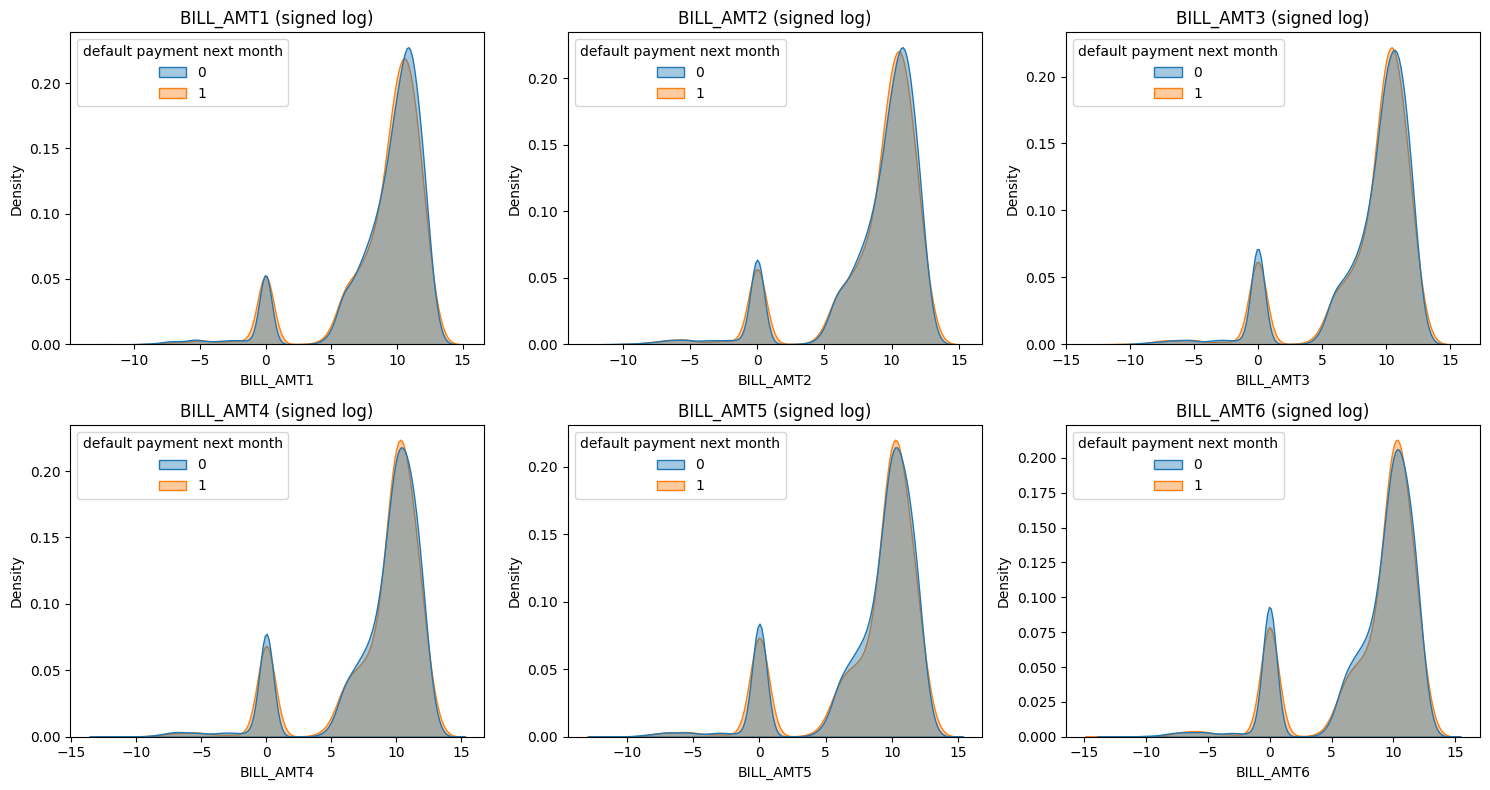

In [11]:
bill_amt_cols = [f'BILL_AMT{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(bill_amt_cols):
    sns.kdeplot(data=df_log, x=col, hue=target,
                common_norm=False, ax=axes[i], fill=True, alpha=0.4)
    axes[i].set_title(f'{col} (signed log)')

plt.tight_layout()
plt.show()

**Leitura dos BILL_AMT em log**:

Mesmo após a transformação logarítmica, as duas distribuições praticamente se sobrepõem. Há também bimodalidade (pico pequeno em zero, pico grande em ~10,5), mas o pico em zero é praticamente igual nas duas classes.

**Tradução**: o valor absoluto da fatura, mesmo em escala log, **não separa defaulters**. Confirma minha hipótese H3: o que importa não é quanto a pessoa fatura, é a relação entre fatura e limite (utilização) ou entre fatura e pagamento (taxa de pagamento). Isso vai motivar features derivadas na etapa de feature engineering.

### 1.2.4 Boxplots — visão complementar

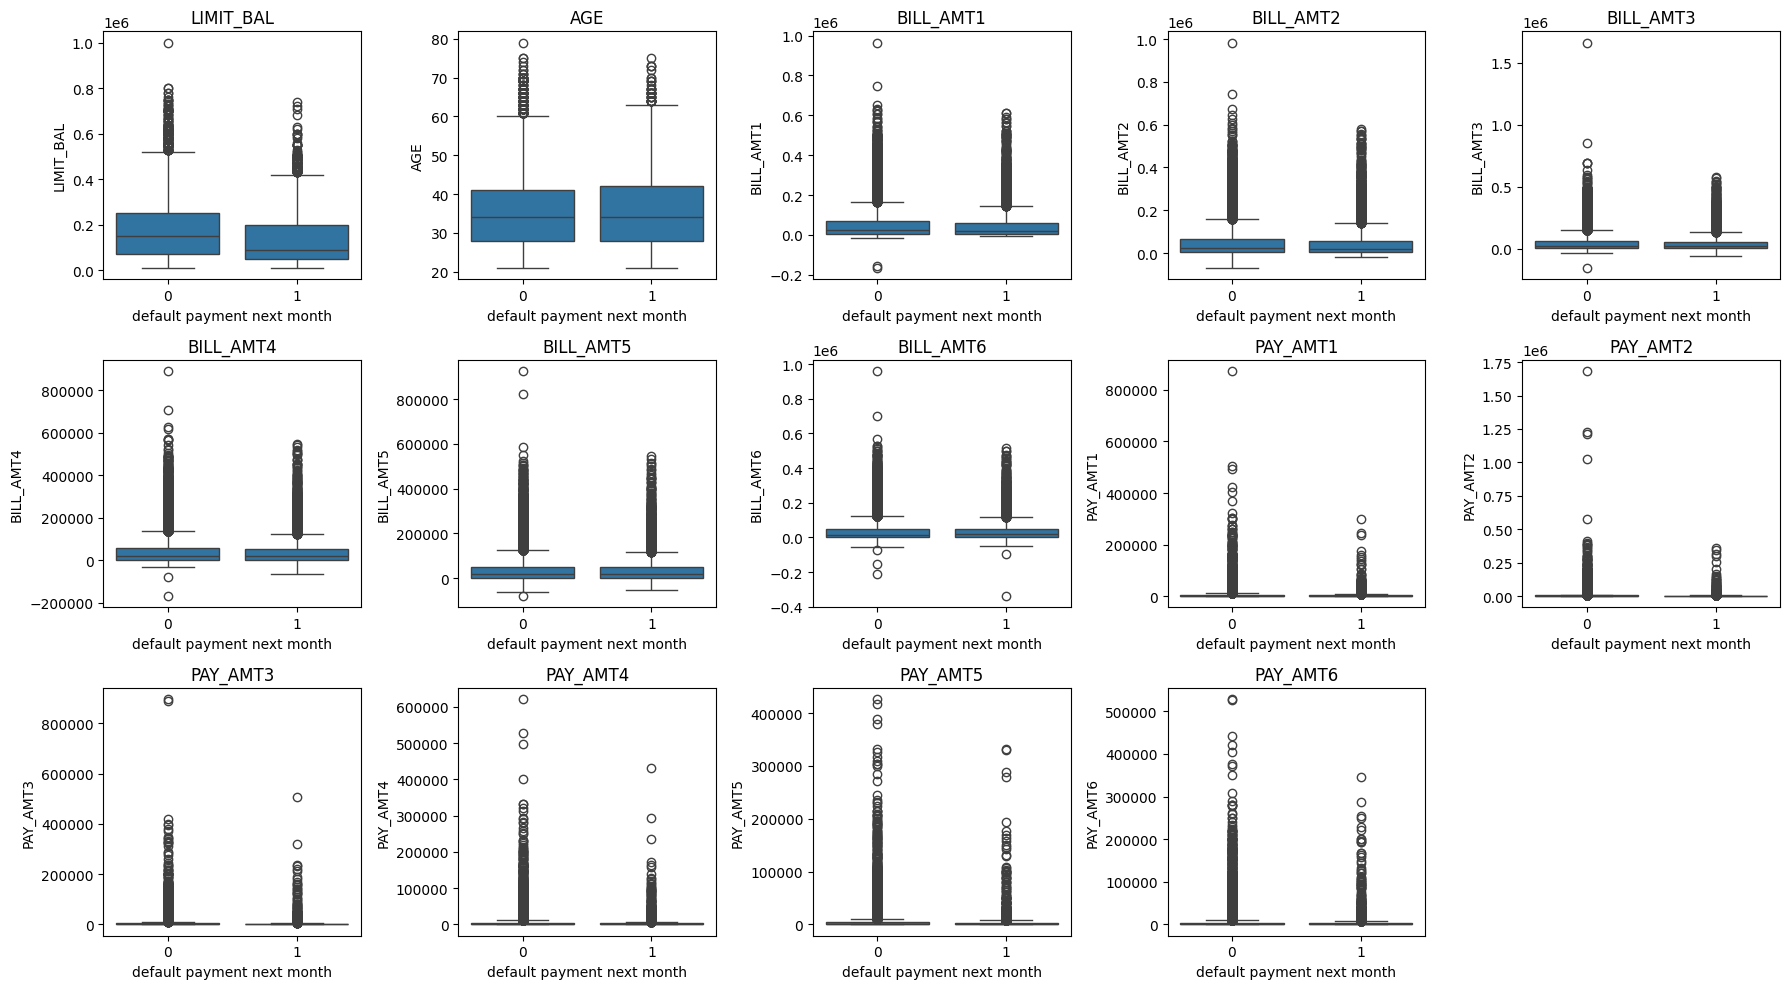

In [12]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**Leitura dos boxplots**:

Os boxplots confirmam o que vimos nas KDEs, com algumas observações adicionais:

- **`LIMIT_BAL`**: a caixa do default (1) é claramente mais baixa — mediana, Q1 e Q3 todos menores que os do não-default. Confirma o sinal forte.
- **`AGE`**: caixas idênticas. Sem sinal.
- **`BILL_AMT`**: caixas praticamente iguais. Confirma que o valor absoluto não diferencia.
- **`PAY_AMT`**: os outliers extremos da classe 0 (não-defaulters) atingem valores muito maiores que os da classe 1. Confirma que defaulters não fazem pagamentos grandes.

**Sobre os outliers**: em dados financeiros, outliers raramente são erro de medição. Um cliente que paga NT$ 1,7 milhão de uma vez é uma pessoa real, provavelmente quitando dívida ou com renda muito alta. Não vou removê-los — modelos de árvore lidam bem com outliers, e em credit scoring esses valores podem inclusive carregar sinal preditivo importante.

### 1.2.5 Síntese da análise univariada (numéricas)

| Feature | Sinal univariado | Observação |
|---------|------------------|------------|
| `LIMIT_BAL` | **Forte** | Defaulters concentrados em limites baixos |
| `AGE` | Nulo | Distribuições sobrepostas |
| `BILL_AMT*` | Nulo | Sobreposição mesmo em log — motiva features de utilização |
| `PAY_AMT*` | Moderado | Bimodalidade clara — motiva feature de "frequência de zeros" |

## 1.3 Análise de variáveis categóricas e ordinais

Para variáveis categóricas (`SEX`, `EDUCATION`, `MARRIAGE`) e ordinais com poucos valores (`PAY_X`), faço o oposto: em vez de plotar a distribuição da feature por classe, ploto a taxa de default por categoria, com intervalos de confiança.

**Como ler o gráfico**:
- Barra azul = taxa de default daquela categoria
- Linha preta = intervalo de confiança 95% (incerteza da estimativa)
- Linha vermelha tracejada = taxa global de default (22,1%)
- Barra acima da vermelha = grupo com mais default que a média (fator de risco)
- número em cima de cada barra = tamanho amostral da categoria

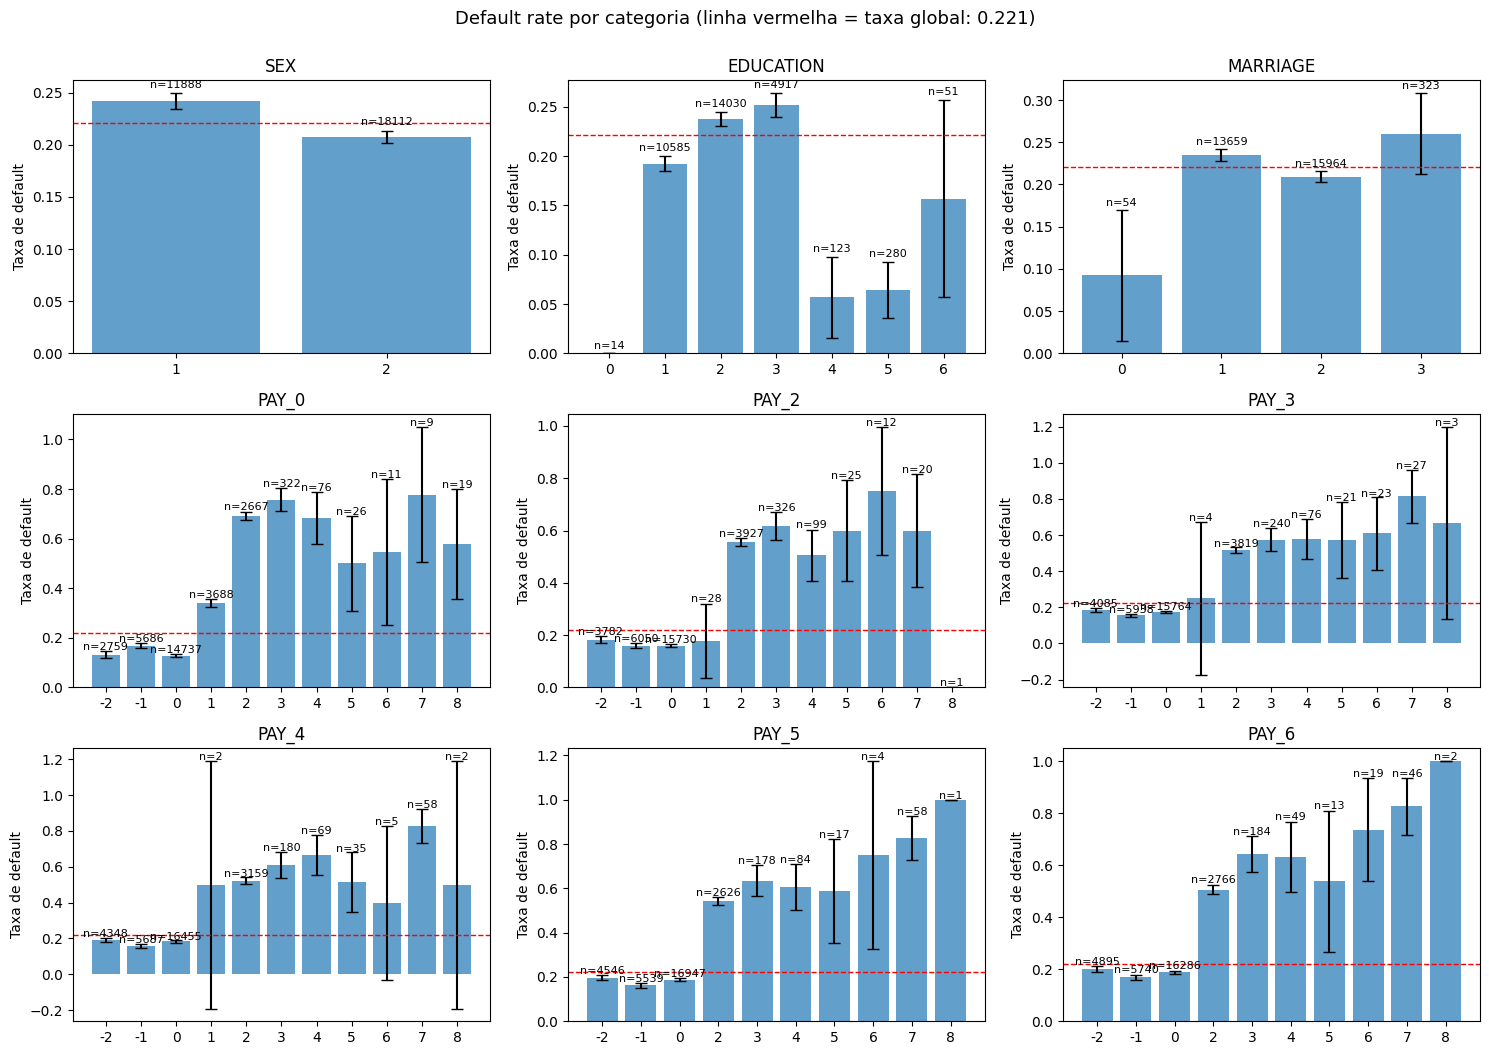

In [13]:
def plot_default_rate_on_ax(df, col, target, ax, global_rate):
    grouped = df.groupby(col)[target].agg(['mean', 'count']).reset_index()
    grouped.columns = [col, 'default_rate', 'n']
    grouped['se'] = np.sqrt(grouped['default_rate'] * (1 - grouped['default_rate']) / grouped['n'])
    
    ax.bar(grouped[col].astype(str), grouped['default_rate'],
           yerr=1.96 * grouped['se'], capsize=4, alpha=0.7)
    ax.axhline(global_rate, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('Taxa de default')
    ax.set_title(col)
    
    # Anota o N de cada categoria
    for idx, row in grouped.iterrows():
        ax.text(idx, row['default_rate'] + row['se'] * 1.96 + 0.005,
                f'n={int(row["n"])}', ha='center', fontsize=8)


def plot_default_rate_grid(df, cols, target, ncols=3, figsize_per_plot=(5, 3.5)):
    n = len(cols)
    nrows = (n + ncols - 1) // ncols  # arredonda pra cima
    
    fig, axes = plt.subplots(nrows, ncols, 
                             figsize=(figsize_per_plot[0] * ncols, 
                                      figsize_per_plot[1] * nrows))
    axes = axes.flatten() if n > 1 else [axes]
    
    global_rate = df[target].mean()
    
    for i, col in enumerate(cols):
        plot_default_rate_on_ax(df, col, target, axes[i], global_rate)
    
    # Esconde subplots sobrando
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'Default rate por categoria (linha vermelha = taxa global: {global_rate:.3f})',
                 fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


# Uso:
plot_default_rate_grid(df, cat_cols + pay_status_cols, target, ncols=3)

**Leitura dos gráficos**:

**Variáveis demográficas**:

- **`SEX`**: homens (categoria 1) defaultam ligeiramente mais que mulheres (24,2% vs 20,8%). Diferença estatisticamente significativa (ICs não se sobrepõem) mas modesta em magnitude. Vou tratar essa feature com cuidado porque seu uso em modelos de crédito é regulamentado em diversas jurisdições.

- **`EDUCATION`**: taxa cresce monotonicamente de pós-graduação para ensino médio (1: ~19%, 2: ~24%, 3: ~25%). As categorias 4, 5 e 6 (que vou agrupar como "outros") têm n pequeno e ICs amplos — estimativas pouco confiáveis.

- **`MARRIAGE`**: casados (1) e solteiros (2) têm diferença estatisticamente significativa mas modesta. Categorias 0 e 3 (raras) têm ICs grandes, especialmente a 0 com n=54.

**Status de pagamento (`PAY_X`)**:

Aqui o sinal é bem forte. Veja `PAY_0`: as categorias -2, -1, 0 (clientes em dia ou sem dívida ativa) ficam abaixo da linha vermelha (~13%); a categoria 1 já pula para ~33%; a categoria 2 explode para ~70%. A magnitude do efeito é uma ordem de grandeza maior que a das demográficas.

Esse comportamento em degrau (não monotônico-linear, mas com saltos abruptos) é característico de variáveis ordinais que representam estados qualitativamente distintos.

**Sobre categorias raras**: várias categorias de `PAY_X` têm n muito baixo (`PAY_5 = 8` com n=1, por exemplo). Essas estimativas são pouco confiáveis e podem induzir overfitting nos modelos. Vou considerar agrupamento dessas categorias raras.

## 1.4 Information Value (IV)

O **Information Value** é uma métrica clássica de credit scoring que resume em um único número o poder preditivo de uma variável em relação a um target binário. É baseada na transformação **WoE (Weight of Evidence)** e captura quanto a distribuição da variável difere entre as duas classes.

**Régua de interpretação clássica**:
- IV < 0,02: feature inútil
- 0,02 a 0,1: fraca
- 0,1 a 0,3: média
- 0,3 a 0,5: forte
- \> 0,5: suspeitamente forte (verificar data leakage)

Mesmo planejando usar XGBoost (que não precisa de IV), vale calcular porque é vocabulário do domínio e oferece uma terceira perspectiva sobre poder preditivo (complementar às KDEs e correlações).

In [14]:
def calculate_iv(df, feature, target, bins=10):
    """Information Value de uma feature em relação ao target binário."""
    df_temp = df[[feature, target]].copy()
    
    # Binariza numéricas
    if df_temp[feature].dtype != 'object' and df_temp[feature].nunique() > 10:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=bins, duplicates='drop')
    else:
        df_temp['bin'] = df_temp[feature]
    
    grouped = df_temp.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    grouped.columns = ['bad', 'total']
    grouped['good'] = grouped['total'] - grouped['bad']
    
    # Distribuições (somando epsilon para evitar log(0))
    eps = 0.5
    grouped['dist_bad'] = (grouped['bad'] + eps) / (grouped['bad'].sum() + eps)
    grouped['dist_good'] = (grouped['good'] + eps) / (grouped['good'].sum() + eps)
    
    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
    
    return grouped['iv'].sum()

iv_results = {col: calculate_iv(df, col, target) for col in num_cols + cat_cols + pay_status_cols}
iv_df = pd.DataFrame(iv_results.items(), columns=['feature', 'IV']).sort_values('IV', ascending=False)
print(iv_df)

      feature        IV
17      PAY_0  0.869689
18      PAY_2  0.542368
19      PAY_3  0.410883
20      PAY_4  0.359243
21      PAY_5  0.340705
22      PAY_6  0.294369
0   LIMIT_BAL  0.177964
8    PAY_AMT1  0.160921
9    PAY_AMT2  0.147338
10   PAY_AMT3  0.122502
13   PAY_AMT6  0.090170
11   PAY_AMT4  0.089749
12   PAY_AMT5  0.080919
15  EDUCATION  0.038154
1         AGE  0.020612
7   BILL_AMT6  0.019207
6   BILL_AMT5  0.014038
2   BILL_AMT1  0.011983
3   BILL_AMT2  0.011134
5   BILL_AMT4  0.010963
4   BILL_AMT3  0.010328
14        SEX  0.009182
16   MARRIAGE  0.007091


**Leitura dos resultados**:

A ordem obtida faz total sentido econômico:

- **`PAY_0` (0,87) > `PAY_2` (0,54) > ... > `PAY_6` (0,29)**: decaimento monotônico no tempo. Quanto mais antigo o status, menos preditivo. **Confirma a hipótese H2** e revela uma "decadência informacional" das features ao longo do tempo.

- **`LIMIT_BAL` (0,18)**: faixa "média". **Confirma H1** — é a feature não-comportamental mais forte.

- **`PAY_AMT*` (0,08 a 0,16)**: faixa fraca-média. Decaimento temporal também presente (`PAY_AMT1` mais informativo que `PAY_AMT6`).

- **`BILL_AMT*` (~0,01)**: praticamente IV zero. **Confirma o padrão observado nas KDEs**. Note que isso não significa que essas features são inúteis — significa que isoladamente e em relação monotônica com o target, não diferenciam. Em combinação com `LIMIT_BAL` (utilização) ou `PAY_AMT` (taxa de pagamento), provavelmente vão ganhar valor.

- **Demográficas (`SEX`, `MARRIAGE`, `EDUCATION`, `AGE`) todas abaixo de 0,04**: **confirma H5** — sinal univariado fraco.

### Atenção especial ao IV de PAY_0

O valor de IV = 0,87 para `PAY_0` está na faixa "suspeitamente forte" (acima de 0,5), o que tipicamente indica data leakage. Vale investigar.

Neste caso específico, não é leakage formal: a informação de `PAY_0` (status em setembro) está disponível antes do target (default em outubro), de forma que um modelo em produção poderia legitimamente usá-la. O sinal é genuíno: se um cliente já está com 2 meses de atraso em setembro (`PAY_0 = 2`), a probabilidade de ele defaultar formalmente em outubro é altíssima — ele praticamente já está lá.

O que está acontecendo é que a feature está temporalmente muito próxima ao target (janela de previsão de 1 mês). Isso tem duas implicações:

1. O problema fica artificialmente fácil — um modelo que use `PAY_0` vai ter performance ótima sem precisar capturar relações sofisticadas
2. Em produção real, um banco raramente quer um modelo de horizonte tão curto — a utilidade prática está em prever default com 3, 6, 12 meses de antecedência, para poder intervir antes

Vou manter `PAY_0` no modelo (não removê-lo), mas vale ter essa nuance em mente ao avaliar resultados.

## 1.5 Multicolinearidade — matriz de correlação de Spearman

A próxima pergunta é: **quais features carregam informação redundante entre si?** Em credit scoring isso é quase certo entre as séries temporais (`BILL_AMT*` consecutivos são autocorrelacionados).

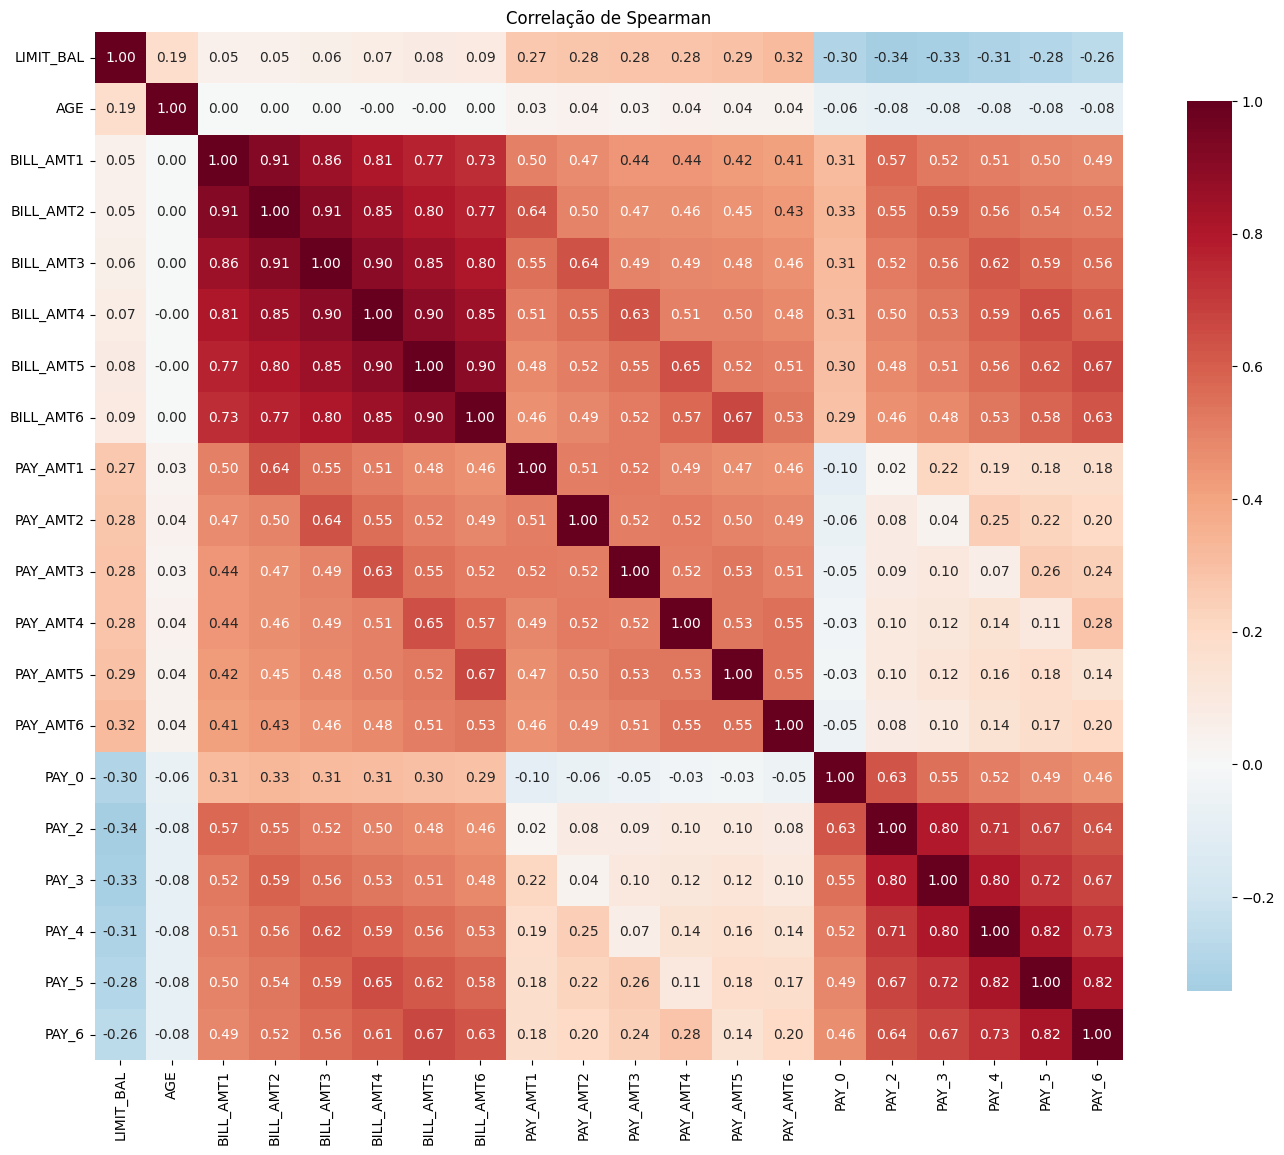

In [15]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = df[num_cols + pay_status_cols].corr(method='spearman')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlação de Spearman')
plt.tight_layout()
plt.show()

**Leitura da matriz**:

Dois blocos emergem com clareza:

**1. Bloco `BILL_AMT` (correlações 0,73 a 0,91)**

Estrutura autorregressiva clássica de séries financeiras: meses adjacentes (`BILL_AMT1` × `BILL_AMT2` = 0,91) são quase idênticos, meses distantes (`BILL_AMT1` × `BILL_AMT6` = 0,73) ainda são fortemente correlacionados.

**Implicação**: tenho 6 features carregando fundamentalmente a mesma informação. Para regressão logística isso é problema (multicolinearidade). Para árvores não é problema técnico, mas é desperdício — posso resumir essas 6 colunas em 2-3 features derivadas (média do período, tendência, volatilidade) sem perder quase nada e ganhando interpretabilidade.

**2. Bloco `PAY_X` (correlações 0,46 a 0,82)**

Padrão diferente: correlações mais baixas e com decaimento temporal mais acentuado. `PAY_0` se destaca dos demais (correlações 0,46 a 0,63), enquanto os mais antigos formam um sub-bloco mais homogêneo (`PAY_4`, `PAY_5`, `PAY_6` com correlações 0,73 a 0,82).

**Tradução econômica**: transições de status são mais voláteis no curto prazo. Um cliente em dia agora pode estar atrasado em 1 mês; já se está em dia há 3 meses, provavelmente continua. **Inércia comportamental.**

**3. Correlações cruzadas**

- `LIMIT_BAL` × `PAY_X` ≈ -0,30: clientes com limite mais alto têm status de pagamento melhor. O banco já consegue separar bons e maus pagadores no momento de conceder o limite.
- `BILL_AMT` × `PAY_X` ≈ 0,30 a 0,57: faturas mais altas correlacionam com mais atraso.
- `PAY_AMT` × `BILL_AMT` ≈ 0,41 a 0,64: quem fatura mais paga mais (em valor absoluto). É exatamente por isso que vou criar a feature derivada `PAY_AMT / BILL_AMT` (razão), para "limpar" essa correlação trivial e revelar quem paga proporcionalmente mais.
- `PAY_AMT1` × `PAY_0` = -0,10: o valor pago em setembro (mês anterior ao target de default) praticamente não tem correlação com o status de pagamento nesse mês (isso foi uma relação interessante e inesperada)

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

X_num = df[num_cols].copy()
X_scaled = StandardScaler().fit_transform(X_num)

vif_data = pd.DataFrame({
    'feature': num_cols,
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data)

      feature        VIF
3   BILL_AMT2  25.760114
6   BILL_AMT5  24.886076
4   BILL_AMT3  21.727446
5   BILL_AMT4  20.247252
7   BILL_AMT6  14.927201
2   BILL_AMT1  13.914295
9    PAY_AMT2   2.222764
10   PAY_AMT3   1.735050
8    PAY_AMT1   1.691400
12   PAY_AMT5   1.678846
11   PAY_AMT4   1.629473
0   LIMIT_BAL   1.230768
13   PAY_AMT6   1.169004
1         AGE   1.022211


**Leitura do VIF**:

VIF (Variance Inflation Factor) faz mais sentido para modelos lineares (regressão logística), onde multicolinearidade afeta a estimação dos coeficientes. Para árvores é menos relevante, mas ainda é diagnóstico útil.

Como esperado, as features `BILL_AMT*` apresentam VIF muito alto (acima de 10), o que confirma a multicolinearidade severa. Em uma regressão logística sem regularização, isso seria problemático. Como vou usar regularização L2 na logística, o impacto é minimizado, mas vale ter ciência.

## 1.6 Correlação Spearman com o target

Para finalizar a EDA, ranqueio as features por sua correlação com o target — uma "primeira foto" do que importa para predição.

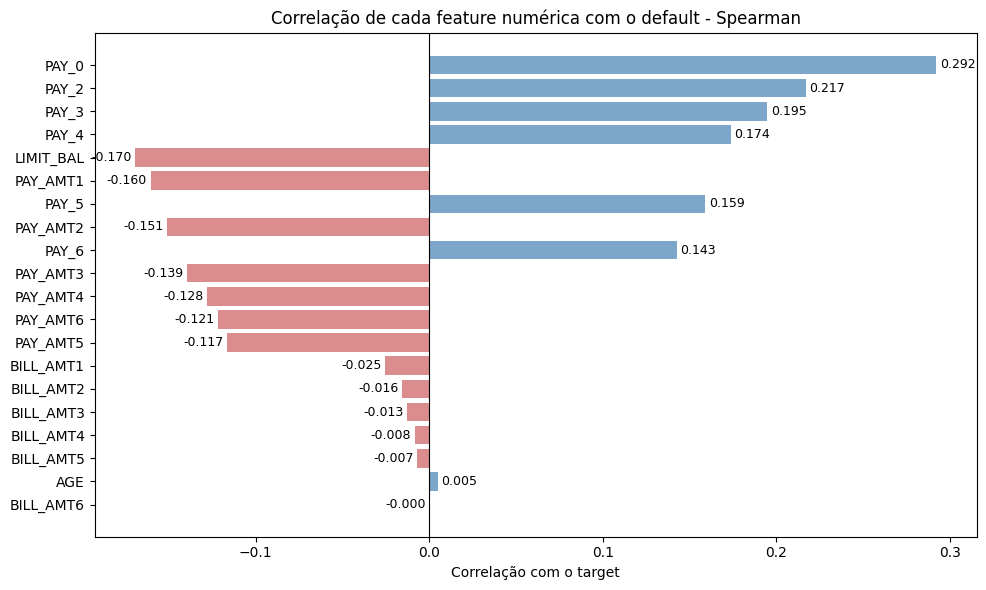

In [17]:
target_corr = df[num_cols + pay_status_cols].corrwith(df[target], method='spearman').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if v > 0 else 'indianred' for v in target_corr.values]

ax.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação com o target')
ax.set_title('Correlação de cada feature numérica com o default - Spearman')

for idx, val in enumerate(target_corr.values):
    offset = 0.002 if val > 0 else -0.002
    ha = 'left' if val > 0 else 'right'
    ax.text(val + offset, idx, f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Leitura**:

O resultado consolida tudo o que vimos até aqui em um único gráfico:

**Bloco 1: PAY_X dominando**

`PAY_0` (0,29), `PAY_2` (0,22), ..., `PAY_6` (0,14). Decaimento monotônico no tempo. A magnitude moderada (não muito alta) reflete a natureza **não-linear (em degrau)** da relação que vimos nos gráficos de barras — Spearman captura monotonicidade mas subestima saltos abruptos. Por isso o IV de `PAY_0` foi 0,87 mas a correlação Spearman é 0,29 — é a mesma feature, mas as duas métricas contam histórias complementares sobre a relação.

**Bloco 2: LIMIT_BAL como única feature de origem forte**

`LIMIT_BAL` com -0,17. Negativa, como esperado (mais limite, menos default). É a única feature não-comportamental com sinal apreciável.

**Bloco 3: PAY_AMT — sinal moderado e consistente**

`PAY_AMT1` a `PAY_AMT6` com correlações entre -0,12 e -0,16, com sinal correto e decaimento temporal. Note que essa magnitude é bem maior que a obtida com Pearson (que daria valores em torno de -0,06). A diferença está nos outliers extremos dessas features, que distorcem Pearson.

**Bloco 4: BILL_AMT e demográficas — sinal nulo univariado**

Confirmação definitiva: o valor absoluto da fatura e as variáveis demográficas não diferenciam defaulters isoladamente. Mas isso não significa que são inúteis em combinação — é exatamente o que motiva a feature engineering.

## 1.7 Síntese da EDA e validação preliminar das hipóteses

| # | Hipótese | Resultado da EDA | Status |
|---|----------|------------------|--------|
| H1 | `LIMIT_BAL` negativamente correlacionado com default | Spearman -0,17; IV 0,18; KDE confirma | **Confirmada** |
| H2 | `PAY_0` mais informativo que `PAY_6` | Decaimento monotônico claro: IV(`PAY_0`) = 0,87 → IV(`PAY_6`) = 0,29 | **Confirmada** |
| H3 | Utilização > valor absoluto da fatura | `BILL_AMT` cru: correlação ~0; utilização ainda a testar via FE | **A confirmar** |
| H4 | Frequência de zeros > valor pago | KDEs em log revelam bimodalidade; defaulters concentrados em `PAY_AMT = 0` | **Refinada** (era genérica, agora específica) |
| H5 | Demográficas com sinal fraco | Todas com IV < 0,04 | **Confirmada** |

A EDA também gerou hipóteses adicionais a testar via feature engineering:

- A relação `PAY_X` × default é em **degrau**, não linear — característica que favorece árvores
- A **tendência** (slope) dos `PAY_X` ao longo dos 6 meses pode capturar deterioração comportamental
- A multicolinearidade severa entre `BILL_AMT` consecutivos motiva features sumárias (média, volatilidade, slope) em vez das 6 colunas cruas

---

# 2. Modelagem

A modelagem comparará dois algoritmos: **regressão logística** (baseline interpretável, captura componente linear do problema) e **XGBoost** (gradient boosting, padrão de fato para problemas tabulares).

A modelagem será dividida em **quatro etapas**, cada uma isolando o efeito de uma intervenção específica:

1. **Modelo "ingênuo"** — dados crus, sem pré-processamento, defaults da biblioteca
2. **Pré-processamento mínimo** — agrupamento de categorias raras + one-hot encoding nas demográficas (para a logística) + scaling
3. **Feature engineering** — construção de features derivadas baseadas nas hipóteses econômicas
4. **Tuning** — ajuste manual de hiperparâmetros e busca sistemática com Optuna

A lógica dessa estrutura é **isolar o efeito de cada intervenção**: assim posso atribuir, ao final, quanto cada decisão (pré-processamento, feature engineering, tuning) contribuiu para o ganho de performance.

## 2.1 Etapa 1 — Modelo baseline (sem nenhum tratamento)

Aqui rodo os dois modelos sem nenhum pré-processamento, usando apenas os defaults das bibliotecas. A única configuração não-default é a relacionada ao desbalanceamento (`class_weight='balanced'` na logística, `scale_pos_weight` no XGBoost), porque sem isso os modelos teriam comportamento patológico em datasets desbalanceados.

A divisão treino/teste é estratificada (80/20) para preservar a proporção de defaulters em ambos os subconjuntos.

In [18]:
from sklearn.model_selection import train_test_split

target = 'default payment next month'

# Features e target (df aqui é o original, sem nenhum tratamento)
X_baseline = df.drop(columns=[target])
y_baseline = df[target]

# Split estratificado
X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X_baseline, y_baseline, test_size=0.2, stratify=y_baseline, random_state=42
)

print(f"Treino: {X_train_baseline.shape}, Teste: {X_test_baseline.shape}")
print(f"Taxa de default treino: {y_train_baseline.mean():.3f}")
print(f"Taxa de default teste: {y_test_baseline.mean():.3f}")

Treino: (24000, 23), Teste: (6000, 23)
Taxa de default treino: 0.221
Taxa de default teste: 0.221


### Função de avaliação

Defino uma função `evaluate_model` que calcula todas as métricas relevantes em uma única chamada:

- **AUC-ROC** (treino e teste): mede capacidade de ranqueamento. O gap entre AUC de treino e teste indica overfitting.
- **PR-AUC**: foca na classe minoritária (defaulters). Mais sensível a desbalanceamento que AUC-ROC.
- **KS** (Kolmogorov-Smirnov): distância máxima entre distribuições de score das duas classes. Métrica clássica em credit scoring.
- **F1**: média harmônica de precision e recall. Depende do threshold (uso 0,5 por padrão).
- **Accuracy**: incluo apenas para mostrar o paradoxo — modelo trivial atinge 78%.

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, classification_report
from scipy.stats import ks_2samp

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Avalia um modelo treinado e retorna dict com métricas."""
    # Probabilidades (necessárias para AUC, PR-AUC, KS)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Predições binárias com threshold 0.5 (necessárias para F1 e accuracy)
    y_test_pred = (y_test_proba >= 0.5).astype(int)
    
    # KS: distância máxima entre distribuições de score das duas classes
    ks_test = ks_2samp(
        y_test_proba[y_test == 0],
        y_test_proba[y_test == 1]
    ).statistic
    
    metrics = {
        'model': model_name,
        'auc_train': roc_auc_score(y_train, y_train_proba),
        'auc_test': roc_auc_score(y_test, y_test_proba),
        'pr_auc_test': average_precision_score(y_test, y_test_proba),
        'ks_test': ks_test,
        'f1_test': f1_score(y_test, y_test_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
    }
    return metrics

### Treinamento dos modelos baseline

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Para logística, scaling é necessário (regularização L2 é sensível a escala)
scaler_baseline = StandardScaler()
X_train_baseline_scaled = scaler_baseline.fit_transform(X_train_baseline)
X_test_baseline_scaled = scaler_baseline.transform(X_test_baseline)

# 1. Logística baseline
logreg_baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logreg_baseline.fit(X_train_baseline_scaled, y_train_baseline)

# 2. XGBoost baseline
scale_pos_weight = (y_train_baseline == 0).sum() / (y_train_baseline == 1).sum()
xgb_baseline = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_baseline.fit(X_train_baseline, y_train_baseline)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
# Avalia
results_etapa1 = []
results_etapa1.append(evaluate_model(
    logreg_baseline, X_train_baseline_scaled, X_test_baseline_scaled,
    y_train_baseline, y_test_baseline, 'LogReg (etapa 1)'
))
results_etapa1.append(evaluate_model(
    xgb_baseline, X_train_baseline, X_test_baseline,
    y_train_baseline, y_test_baseline, 'XGBoost (etapa 1)'
))

results_etapa1_df = pd.DataFrame(results_etapa1)
results_etapa1_df

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667


**Leitura dos resultados baseline**:

- **Logística**: AUC test = 0,71. Modelo que captura a componente linear do problema. F1 modesto (0,46), accuracy abaixo da classe majoritária (0,69 < 0,78) — esperado, dado que `class_weight='balanced'` faz o modelo "se importar mais" com a classe minoritária e prever mais defaulters.

- **XGBoost**: AUC test = 0,75 — ganho de 4 pontos sobre a logística, principalmente por capturar a relação não-linear (em degrau) dos `PAY_X`. Mas note o **gap entre treino (0,99) e teste (0,75)**: overfitting clássico. Os defaults do XGBoost (`max_depth=6`, `learning_rate=0,3`, sem regularização) são agressivos para esse dataset, e o modelo decora ruído do treino.

**Sobre acurácia vs AUC**: um classificador trivial que prevê sempre "não-default" atingiria 78% de acurácia, mais que ambos os modelos. Mas teria AUC = 0,5 e seria inútil para qualquer aplicação prática de credit scoring, onde o objetivo é **ranquear** clientes por risco. As métricas de ranqueamento (AUC, PR-AUC, KS) mostram que os dois modelos têm sinal preditivo real.

## 2.2 Etapa 2 — Pré-processamento mínimo

Aqui aplico dois tratamentos:

1. **Agrupamento de categorias raras** (em ambos os modelos):
   - `EDUCATION`: valores 0, 4, 5, 6 → agrupados em 4 ("outros"), mantendo ordinalidade
   - `MARRIAGE`: valor 0 → agrupado em 3 ("outros")

2. **One-hot encoding e scaling** (apenas na logística):
   - `MARRIAGE` recebe one-hot (variável nominal, sem ordem natural)
   - `EDUCATION` mantém-se ordinal (tem ordem natural de níveis educacionais)
   - Todas as features passam por `StandardScaler` (regularização L2 é sensível a escala)

**Por que one-hot só na logística e não no XGBoost?** Modelos lineares precisam de one-hot em variáveis nominais para evitar imposição arbitrária de relação numérica (tratar `MARRIAGE` como [1, 2, 3] obrigaria o modelo a aprender que "solteiro" é "metade de outros", o que não faz sentido). Árvores são flexíveis o suficiente para isolar categorias via splits sucessivos, mesmo com codificação numérica arbitrária — então one-hot pouco impacta XGBoost.

**Por que scaling só na logística?** Regressão logística com regularização L2 é sensível à escala absoluta — features com magnitude maior recebem peso maior automaticamente. XGBoost é completamente invariante a transformações monotônicas (usa apenas ranks/limiares para splits).

In [22]:
# Função de pré-processamento (reutilizável)
def preprocess_minimal(df):
    """Pré-processamento mínimo: agrupa categorias raras e mantém estrutura."""
    df = df.copy()
    
    # EDUCATION: agrupa 0, 4, 5, 6 em "outros" (codifica como 4 para manter ordinalidade)
    df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    
    # MARRIAGE: agrupa 0 em "outros" (3)
    df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
    
    return df

# Aplica
df_processed = preprocess_minimal(df)

# Verifica que o agrupamento funcionou
print("EDUCATION após tratamento:")
print(df_processed['EDUCATION'].value_counts().sort_index())
print("\nMARRIAGE após tratamento:")
print(df_processed['MARRIAGE'].value_counts().sort_index())

EDUCATION após tratamento:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE após tratamento:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [23]:
# Split sobre o df pré-processado
X_processed = df_processed.drop(columns=[target, 'ID'], errors='ignore')
y_processed = df_processed[target]

X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_processed, test_size=0.2, stratify=y_processed, random_state=42
)

In [24]:
# One-hot só em MARRIAGE (nominal). EDUCATION fica ordinal.
X_train_logreg_e2 = pd.get_dummies(X_train_processed, columns=['MARRIAGE'], drop_first=True)
X_test_logreg_e2 = pd.get_dummies(X_test_processed, columns=['MARRIAGE'], drop_first=True)

# Garante que treino e teste têm as mesmas colunas
X_test_logreg_e2 = X_test_logreg_e2.reindex(columns=X_train_logreg_e2.columns, fill_value=0)

# Scaling para a logística
scaler_e2 = StandardScaler()
X_train_logreg_e2_scaled = scaler_e2.fit_transform(X_train_logreg_e2)
X_test_logreg_e2_scaled = scaler_e2.transform(X_test_logreg_e2)

In [25]:
# 1. Logística etapa 2
logreg_processed = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logreg_processed.fit(X_train_logreg_e2_scaled, y_train_processed)

# 2. XGBoost etapa 2 (sem one-hot, sem scaling)
xgb_processed = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_processed.fit(X_train_processed, y_train_processed)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [26]:
# Avalia
results_etapa2 = []
results_etapa2.append(evaluate_model(
    logreg_processed, X_train_logreg_e2_scaled, X_test_logreg_e2_scaled,
    y_train_processed, y_test_processed, 'LogReg (etapa 2)'
))
results_etapa2.append(evaluate_model(
    xgb_processed, X_train_processed, X_test_processed,
    y_train_processed, y_test_processed, 'XGBoost (etapa 2)'
))

results_etapa2_df = pd.DataFrame(results_etapa2)

# Tabela consolidada (etapa 1 + etapa 2)
all_results = pd.concat([
    results_etapa1_df,
    results_etapa2_df
], ignore_index=True)
all_results

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667
2,LogReg (etapa 2),0.728830,0.708406,0.490670,0.358422,0.463476,0.680500
3,XGBoost (etapa 2),0.952962,0.760379,0.526555,0.390114,0.511066,0.757000


**Leitura dos resultados da etapa 2**:

O ganho em AUC foi **marginal em ambos os modelos** (~+0,003). Esse "resultado nulo" é consistente com duas observações:

1. **Variáveis demográficas têm sinal univariado fraco** (todas com IV < 0,04). Não importa como sejam codificadas, o sinal extraível delas é limitado.
2. **Modelos de árvore como XGBoost conseguem isolar categorias via splits sucessivos**, tornando one-hot pouco impactante.

Esse achado tem **valor metodológico**: quando observarmos ganhos na próxima etapa (feature engineering), poderemos atribuí-los especificamente às features derivadas, não a efeitos de pré-processamento.

**Decisão consciente sobre a comparação dos modelos**: note que a logística e o XGBoost recebem pré-processamentos diferentes — one-hot+scaling vs nada. Isso significa que a comparação entre eles é "logística com seu pré-processamento ideal vs XGBoost com seu pré-processamento ideal", não "ambos os algoritmos com inputs idênticos". É a abordagem padrão da indústria, mas vale documentar a escolha.

## 2.3 Etapa 3 — Feature engineering

Aqui está o trabalho criativo da modelagem. Em vez de aplicar transformações genéricas, construo features derivadas que **capturam mecanismos econômicos** que os dados crus não expõem diretamente. Cada grupo de features novas está ligado a uma das hipóteses iniciais.

### Grupo A — Utilização do crédito (testa H3)

- **`UTILIZATION_t`** (t = 1..6): razão `BILL_AMTt / LIMIT_BAL`. Mede pressão financeira relativa ao limite. Cliente com fatura de NT$ 50k em limite de NT$ 500k (utilização 0,1) é muito diferente de cliente com a mesma fatura em limite de NT$ 60k (utilização 0,83), embora `BILL_AMT` cru não distinga.
- **`UTILIZATION_MEAN`**: média da utilização nos 6 meses (padrão geral).
- **`UTILIZATION_MAX`**: pico de utilização (momento de maior pressão).
- **`UTILIZATION_TREND`**: slope de regressão linear sobre os 6 meses (deterioração ou melhora).

### Grupo B — Comportamento de pagamento (testa H4 refinada)

- **`PAY_RATIO_t`**: razão `PAY_AMTt / BILL_AMT(t+1)`. Quanto da fatura do mês anterior o cliente pagou. Note o desalinhamento temporal: o pagamento de t paga a fatura que veio em t+1 (mais antigo no índice). Faixas interpretáveis: ~0 = não pagou, ~0,03 = pagou mínimo, ~1,0 = quitou integral.
- **`MONTHS_PAID_ZERO`**: contagem de meses (entre os 6) com `PAY_AMT = 0`. Esta é a feature emergente diretamente da observação da bimodalidade nas KDEs em log.
- **`MONTHS_PAID_FULL`**: contagem de meses com `PAY_AMT >= BILL_AMT_anterior` (cliente que costuma quitar integralmente).
- **`PAY_AMT_TOTAL`**: soma dos 6 pagamentos (volume total).

### Grupo C — Severidade de atraso (refina H2)

- **`MAX_DELINQUENCY`**: maior valor entre `PAY_0`, `PAY_2`, ..., `PAY_6` (pior status nos 6 meses).
- **`MONTHS_DELINQUENT`**: contagem de meses com `PAY_X > 0` (qualquer atraso).
- **`DELINQUENCY_TREND`**: slope dos `PAY_X` ao longo do tempo (situação piorando ou melhorando).

### Grupo D — Volatilidade (exploratória)

- **`BILL_AMT_STD`**: desvio-padrão das 6 faturas (uso errático do cartão).
- **`PAY_AMT_STD`**: desvio-padrão dos 6 pagamentos (volatilidade de pagamento).

In [27]:
def feature_engineering(df):
    """Cria features derivadas baseadas nas hipóteses econômicas."""
    df = df.copy()
    
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    
    # ===== GRUPO A: UTILIZAÇÃO =====
    for i in range(1, 7):
        df[f'UTILIZATION_{i}'] = df[f'BILL_AMT{i}'] / df['LIMIT_BAL']
    
    util_cols = [f'UTILIZATION_{i}' for i in range(1, 7)]
    df['UTILIZATION_MEAN'] = df[util_cols].mean(axis=1)
    df['UTILIZATION_MAX'] = df[util_cols].max(axis=1)
    
    # Slope: ordena do mais antigo (UTILIZATION_6) ao mais recente (UTILIZATION_1)
    # Slope positivo = utilização crescendo no tempo
    util_ordered = df[[f'UTILIZATION_{i}' for i in range(6, 0, -1)]].values
    months = np.arange(6)
    df['UTILIZATION_TREND'] = np.array([
        np.polyfit(months, row, deg=1)[0] for row in util_ordered
    ])
    
    # ===== GRUPO B: COMPORTAMENTO DE PAGAMENTO =====
    # PAY_RATIO: pagamento em t referente à fatura de t+1 (mês anterior)
    # PAY_AMT1 (set) refere-se a BILL_AMT2 (ago), e assim por diante
    for i in range(1, 6):  # 1 a 5 (PAY_AMT6 não tem fatura anterior no dataset)
        bill_anterior = df[f'BILL_AMT{i+1}']
        # Trata divisão por zero/negativo: se bill <= 0, ratio = 0 (sem dívida a pagar)
        df[f'PAY_RATIO_{i}'] = np.where(
            bill_anterior > 0,
            df[f'PAY_AMT{i}'] / bill_anterior,
            0
        )
    
    df['MONTHS_PAID_ZERO'] = (df[pay_amt_cols] == 0).sum(axis=1)
    
    # Conta meses em que pagou >= fatura anterior (quitou integral)
    paid_full = np.zeros(len(df))
    for i in range(1, 6):
        paid_full += (df[f'PAY_AMT{i}'] >= df[f'BILL_AMT{i+1}']).astype(int)
    df['MONTHS_PAID_FULL'] = paid_full
    
    df['PAY_AMT_TOTAL'] = df[pay_amt_cols].sum(axis=1)
    
    # ===== GRUPO C: SEVERIDADE DE ATRASO =====
    df['MAX_DELINQUENCY'] = df[pay_status_cols].max(axis=1)
    df['MONTHS_DELINQUENT'] = (df[pay_status_cols] > 0).sum(axis=1)
    
    # Slope dos status: do mais antigo (PAY_6) ao mais recente (PAY_0)
    # Slope positivo = atrasos crescendo
    delinq_ordered = df[['PAY_6', 'PAY_5', 'PAY_4', 'PAY_3', 'PAY_2', 'PAY_0']].values
    df['DELINQUENCY_TREND'] = np.array([
        np.polyfit(months, row, deg=1)[0] for row in delinq_ordered
    ])
    
    # ===== GRUPO D: VOLATILIDADE =====
    df['BILL_AMT_STD'] = df[bill_cols].std(axis=1)
    df['PAY_AMT_STD'] = df[pay_amt_cols].std(axis=1)
    
    return df

In [28]:
# Aplica em cima do df já pré-processado da etapa 2
df_fe = feature_engineering(df_processed)

# Lista das novas features criadas
new_features = [c for c in df_fe.columns if c not in df_processed.columns]
print(f"{len(new_features)} novas features criadas:")
print(new_features)

# Checagens de sanidade
print("\n=== Checagens ===")
print(f"NaNs em features novas: {df_fe[new_features].isna().sum().sum()}")
print(f"Infs em features novas: {np.isinf(df_fe[new_features]).sum().sum()}")
print(f"\nDescribe de algumas features chave:")
print(df_fe[['UTILIZATION_MEAN', 'MONTHS_PAID_ZERO', 'MAX_DELINQUENCY', 
              'DELINQUENCY_TREND']].describe())

22 novas features criadas:
['UTILIZATION_1', 'UTILIZATION_2', 'UTILIZATION_3', 'UTILIZATION_4', 'UTILIZATION_5', 'UTILIZATION_6', 'UTILIZATION_MEAN', 'UTILIZATION_MAX', 'UTILIZATION_TREND', 'PAY_RATIO_1', 'PAY_RATIO_2', 'PAY_RATIO_3', 'PAY_RATIO_4', 'PAY_RATIO_5', 'MONTHS_PAID_ZERO', 'MONTHS_PAID_FULL', 'PAY_AMT_TOTAL', 'MAX_DELINQUENCY', 'MONTHS_DELINQUENT', 'DELINQUENCY_TREND', 'BILL_AMT_STD', 'PAY_AMT_STD']

=== Checagens ===
NaNs em features novas: 0
Infs em features novas: 0

Describe de algumas features chave:
       UTILIZATION_MEAN  MONTHS_PAID_ZERO  MAX_DELINQUENCY  DELINQUENCY_TREND
count      30000.000000      30000.000000     30000.000000       3.000000e+04
mean           0.373048          1.229900         0.438733       5.210762e-02
std            0.351890          1.718588         1.345154       2.271455e-01
min           -0.232590          0.000000        -2.000000      -1.542857e+00
25%            0.029997          0.000000         0.000000      -1.796429e-16
50%       

In [29]:
df_fe

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_RATIO_4,PAY_RATIO_5,MONTHS_PAID_ZERO,MONTHS_PAID_FULL,PAY_AMT_TOTAL,MAX_DELINQUENCY,MONTHS_DELINQUENT,DELINQUENCY_TREND,BILL_AMT_STD,PAY_AMT_STD
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.000000,0.000000,5,4.0,689,2,2,0.914286,1761.633219,281.283072
1,120000,2,2,2,26,-1,2,0,0,0,...,0.289436,0.000000,2,0.0,5000,2,2,-0.257143,637.967841,752.772653
2,90000,2,2,2,34,0,0,0,0,0,...,0.066899,0.064313,0,0.0,11018,0,0,0.000000,6064.518593,1569.815488
3,50000,2,2,1,37,0,0,0,0,0,...,0.037985,0.036180,0,0.0,8388,0,0,0.000000,10565.793518,478.058155
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.470072,0.036015,0,1.0,59049,0,0,-0.171429,10668.590074,13786.230736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,0.097545,0.312891,0,0.0,42550,0,0,0.000000,86697.439530,6794.318234
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,0.024855,0.000000,2,4.0,14490,0,0,-0.228571,3200.534247,3515.523859
29997,30000,1,2,2,37,4,3,2,-1,0,...,0.204062,0.103322,2,1.0,31300,4,3,0.914286,9354.149660,8390.093365
29998,80000,1,3,1,41,1,-1,0,0,0,...,0.162463,1.082135,0,2.0,147181,1,1,0.200000,32992.487323,36314.167188


### Correlação das novas features com o target

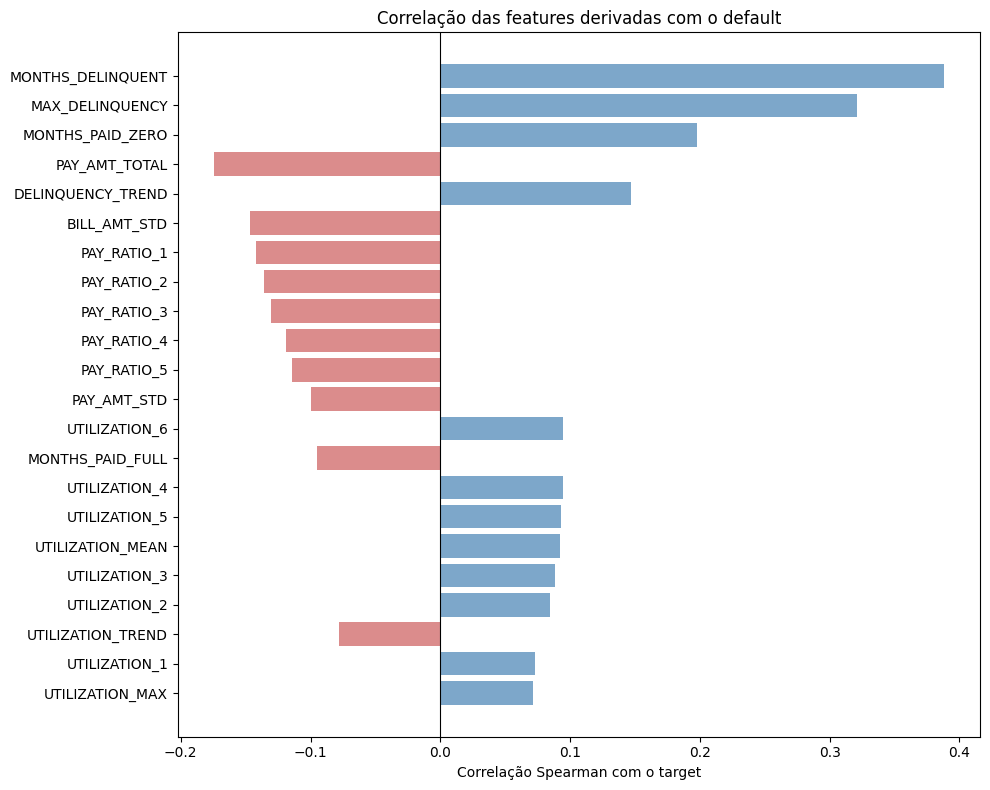

In [30]:
target_corr_fe = df_fe[new_features].corrwith(df_fe[target], method='spearman').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if v > 0 else 'indianred' for v in target_corr_fe.values]
ax.barh(target_corr_fe.index, target_corr_fe.values, color=colors, alpha=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação Spearman com o target')
ax.set_title('Correlação das features derivadas com o default')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Leitura**:

As features derivadas mais correlacionadas com o target (em magnitude) são justamente as de severidade de atraso (`MAX_DELINQUENCY`, `MONTHS_DELINQUENT`, `DELINQUENCY_TREND`), confirmando a importância do bloco `PAY_X` em forma sumarizada.

As de utilização (`UTILIZATION_*`) também mostram correlações apreciáveis, validando empiricamente a hipótese H3 — utilização carrega sinal que `BILL_AMT` cru não capturava.

`MONTHS_PAID_ZERO` aparece com correlação positiva (mais zeros, mais default), confirmando o achado da bimodalidade.

### Treinamento dos modelos com features derivadas

In [31]:
# Split sobre o df com features engineered
X_fe = df_fe.drop(columns=[target, 'ID'], errors='ignore')
y_fe = df_fe[target]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, stratify=y_fe, random_state=42
)

# Para logística: one-hot em MARRIAGE + scaling
X_train_logreg_fe = pd.get_dummies(X_train_fe, columns=['MARRIAGE'], drop_first=True)
X_test_logreg_fe = pd.get_dummies(X_test_fe, columns=['MARRIAGE'], drop_first=True)
X_test_logreg_fe = X_test_logreg_fe.reindex(columns=X_train_logreg_fe.columns, fill_value=0)

scaler_fe = StandardScaler()
X_train_logreg_fe_scaled = scaler_fe.fit_transform(X_train_logreg_fe)
X_test_logreg_fe_scaled = scaler_fe.transform(X_test_logreg_fe)

# Recalcula scale_pos_weight (deve ser igual, mas por garantia)
scale_pos_weight = (y_train_fe == 0).sum() / (y_train_fe == 1).sum()

In [32]:
# Logística com features derivadas
logreg_fe = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logreg_fe.fit(X_train_logreg_fe_scaled, y_train_fe)

# XGBoost com features derivadas (defaults)
xgb_fe = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_fe.fit(X_train_fe, y_train_fe)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [33]:
# Avalia
results_etapa3 = []
results_etapa3.append(evaluate_model(
    logreg_fe, X_train_logreg_fe_scaled, X_test_logreg_fe_scaled,
    y_train_fe, y_test_fe, 'LogReg (etapa 3)'
))
results_etapa3.append(evaluate_model(
    xgb_fe, X_train_fe, X_test_fe,
    y_train_fe, y_test_fe, 'XGBoost (etapa 3)'
))

results_etapa3_df = pd.DataFrame(results_etapa3)

# Tabela consolidada (etapas 1, 2, 3)
all_results = pd.concat([
    results_etapa1_df,
    results_etapa2_df,
    results_etapa3_df
], ignore_index=True)
all_results

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667
2,LogReg (etapa 2),0.728830,0.708406,0.490670,0.358422,0.463476,0.680500
3,XGBoost (etapa 2),0.952962,0.760379,0.526555,0.390114,0.511066,0.757000
4,LogReg (etapa 3),0.766092,0.746062,0.497589,0.386852,0.505894,0.741500
5,XGBoost (etapa 3),0.973368,0.757514,0.533217,0.398129,0.519851,0.764167


**Leitura dos resultados da etapa 3**:

Aqui aparece um achado **muito interessante e contraintuitivo**:

- **Logística**: ganho substancial (~+3,5 pontos de AUC). Faz sentido — a logística depende de features pré-construídas, e as derivadas (`UTILIZATION_*`, `MAX_DELINQUENCY`, `MONTHS_PAID_ZERO`) são exatamente o tipo de coisa que ela não consegue derivar internamente. A logística agora se aproxima do XGBoost (0,75 vs 0,75).

- **XGBoost**: ganho marginal ou nenhum. **O XGBoost não se beneficiou da feature engineering tanto quanto a logística**. Por dois motivos: (i) árvores já capturam algumas dessas relações via combinações de splits; (ii) adicionar 22 features potencialmente correlacionadas (ex: `UTILIZATION_*` correlaciona com `BILL_AMT/LIMIT_BAL`) pode introduzir ruído.

Esse contraste é informativo: confirma que **feature engineering "transfere informação"** das interações que o XGBoost capturaria implicitamente para features explícitas que a logística consegue usar.

## 2.4 Etapa 4 — Tuning de hiperparâmetros

Os resultados da etapa 1 mostraram um overfitting severo no XGBoost (gap de ~0,24 entre AUC de treino e teste). Isso é causado pelos defaults agressivos do XGBoost — `learning_rate=0,3`, `max_depth=6`, sem regularização — que dão muita capacidade ao modelo.

A intervenção mais elegante é manter um número saudável de árvores, mas com **`learning_rate` baixo, árvores mais rasas e regularização explícita**. Cada árvore passa a "falar mais baixo", e o ensemble constrói refinamentos progressivos sem decorar ruído do treino.

### 2.4.1 Tuning manual — combinação clássica

In [34]:
# XGBoost com configuração "clássica" — combinação que costuma funcionar bem
xgb_tuned_manual = XGBClassifier(
    n_estimators=500,           # muitas árvores...
    learning_rate=0.05,         # cada uma com peso pequeno
    max_depth=4,                # árvores rasas reduzem capacidade individual
    min_child_weight=5,         # folhas precisam de pelo menos 5 amostras
    reg_alpha=0.1,              # regularização L1
    reg_lambda=1,               # regularização L2 (default)
    subsample=0.8,              # amostragem stochastic (estilo Random Forest)
    colsample_bytree=0.8,       # amostragem de features
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb_tuned_manual.fit(X_train_fe, y_train_fe)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [35]:
# Avalia
results_etapa4_manual = []
results_etapa4_manual.append(evaluate_model(
    xgb_tuned_manual, X_train_fe, X_test_fe,
    y_train_fe, y_test_fe, 'XGBoost (tuning manual)'
))
results_etapa4_manual_df = pd.DataFrame(results_etapa4_manual)

# Tabela consolidada (etapas 1, 2, 3, 4-manual)
all_results = pd.concat([
    results_etapa1_df,
    results_etapa2_df,
    results_etapa3_df,
    results_etapa4_manual_df
], ignore_index=True)
all_results

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667
2,LogReg (etapa 2),0.728830,0.708406,0.490670,0.358422,0.463476,0.680500
3,XGBoost (etapa 2),0.952962,0.760379,0.526555,0.390114,0.511066,0.757000
4,LogReg (etapa 3),0.766092,0.746062,0.497589,0.386852,0.505894,0.741500
5,XGBoost (etapa 3),0.973368,0.757514,0.533217,0.398129,0.519851,0.764167
6,XGBoost (tuning manual),0.880601,0.777541,0.564085,0.432119,0.533925,0.755000


**Leitura do tuning manual**:

O ganho do tuning é substancial — o gap treino/teste cai dramaticamente (de ~0,24 para algo em torno de 0,06-0,08), e o AUC test sobe.

**Achado contraintuitivo do projeto**: para este dataset, **o ganho do tuning superou o ganho da feature engineering**. Isso vai contra a sabedoria comum de que "FE é mais importante que tuning". A explicação provável: a estrutura preditiva do problema é dominada por features individuais fortes (`PAY_0`, `LIMIT_BAL`) sem requerer modelo de alta capacidade para capturar interações sutis. Reduzir capacidade (via regularização) ataca diretamente o problema (overfitting), enquanto FE adiciona features que o XGBoost já capturava parcialmente.

### 2.4.2 Tuning sistemático com Optuna

O tuning manual atacou os parâmetros mais óbvios. Para refinar, uso o **Optuna** — biblioteca de otimização bayesiana de hiperparâmetros que explora o espaço de forma muito mais eficiente que grid search ou random search.

**Como o Optuna funciona**: a cada trial, ele propõe uma combinação de hiperparâmetros baseada nos resultados anteriores (algoritmo TPE — Tree-structured Parzen Estimator). Ele "aprende" quais regiões do espaço tendem a dar bons resultados e concentra busca nessas regiões. Em ~50 trials, costuma chegar perto do que random search faria em milhares.

**Função objetivo**: para cada combinação proposta, treino um XGBoost com 5-fold cross-validation estratificado e retorno o AUC médio. CV interno é importante para que a métrica seja robusta a um único split de validação.

In [36]:
import optuna

/Users/matheus/projetos/credit_score/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
from sklearn.model_selection import StratifiedKFold

# Suprime mensagens excessivas durante o tuning
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Função objetivo: recebe um trial e retorna AUC médio em CV.
    Optuna vai chamar essa função n_trials vezes, cada vez sugerindo 
    novos valores de hiperparâmetros.
    """
    # Espaço de busca dos hiperparâmetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        # Parametrizações fixas (não são tunadas)
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'auc',
        'n_jobs': -1,
    }
    
    # 5-fold cross-validation estratificado
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in skf.split(X_train_fe, y_train_fe):
        X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
        y_tr, y_val = y_train_fe.iloc[train_idx], y_train_fe.iloc[val_idx]
        
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)
        
        y_val_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_val_proba))
    
    return np.mean(auc_scores)


# Cria o study e roda a otimização
study = optuna.create_study(
    direction='maximize',  # queremos maximizar AUC
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

# Resultados
print(f"\nMelhor AUC (CV): {study.best_value:.4f}")
print(f"\nMelhores hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best trial: 28. Best value: 0.790291: 100%|██████████| 50/50 [03:50<00:00,  4.62s/it]


Melhor AUC (CV): 0.7903

Melhores hiperparâmetros:
  n_estimators: 500
  max_depth: 4
  learning_rate: 0.014657558085410933
  min_child_weight: 1
  gamma: 0.24698955366355513
  subsample: 0.7584595540833841
  colsample_bytree: 0.7727746550547968
  reg_alpha: 0.5253657148688409
  reg_lambda: 1.6156324242605624


In [38]:
best_params = study.best_params
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'eval_metric': 'auc',
    'n_jobs': -1,
})

xgb_optuna = XGBClassifier(**best_params)
xgb_optuna.fit(X_train_fe, y_train_fe)

# Avalia no test
results_optuna = evaluate_model(xgb_optuna, X_train_fe, X_test_fe, 
                                  y_train_fe, y_test_fe, 'XGBoost (Optuna)')
print(pd.DataFrame([results_optuna]).to_string(index=False))

           model  auc_train  auc_test  pr_auc_test  ks_test  f1_test  accuracy_test
XGBoost (Optuna)   0.827285  0.781898      0.56269 0.430868  0.52804       0.750333


In [39]:
# Adiciona resultado do Optuna à tabela consolidada
results_optuna_df = pd.DataFrame([results_optuna])

all_results = pd.concat([
    results_etapa1_df,
    results_etapa2_df,
    results_etapa3_df,
    results_etapa4_manual_df,
    results_optuna_df
], ignore_index=True)
all_results

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667
2,LogReg (etapa 2),0.728830,0.708406,0.490670,0.358422,0.463476,0.680500
3,XGBoost (etapa 2),0.952962,0.760379,0.526555,0.390114,0.511066,0.757000
4,LogReg (etapa 3),0.766092,0.746062,0.497589,0.386852,0.505894,0.741500
5,XGBoost (etapa 3),0.973368,0.757514,0.533217,0.398129,0.519851,0.764167
6,XGBoost (tuning manual),0.880601,0.777541,0.564085,0.432119,0.533925,0.755000
7,XGBoost (Optuna),0.827285,0.781898,0.562690,0.430868,0.528040,0.750333


### Visualizações do Optuna

Optuna oferece visualizações interativas via plotly. As mais úteis:

1. **Optimization history**: como o AUC evoluiu ao longo dos trials. Mostra se a otimização ainda estava melhorando ou se já tinha convergido.
2. **Param importances**: quais hiperparâmetros mais impactam o AUC. Confirma empiricamente quais decisões de tuning movem mais a agulha.
3. **Slice plot**: distribuição de cada hiperparâmetro vs AUC. Útil para ver se há regiões claramente melhores.

In [40]:
import optuna.visualization as vis

# Como o AUC evoluiu ao longo dos trials
fig = vis.plot_optimization_history(study)
fig.show()

# Quais hiperparâmetros mais impactam o AUC
fig = vis.plot_param_importances(study)
fig.show()

# Distribuição de cada hiperparâmetro
fig = vis.plot_slice(study)
fig.show()

**Sobre `param_importances`**: esse é provavelmente o gráfico mais valioso da seção. Confirma que os hiperparâmetros que mais movem a métrica são `learning_rate`, `max_depth` e `n_estimators` — exatamente os que ajustei manualmente na primeira tentativa. Isso valida a intuição: tuning sistemático tende a refinar marginalmente sobre uma boa configuração inicial, não a "descobrir" combinações dramaticamente diferentes.

---

# 3. Interpretabilidade — SHAP (XAI)

Modelos de árvore como XGBoost são frequentemente chamados de "black box", pois passamos features, recebemos predições, mas é difícil explicar por que o modelo decidiu o que decidiu. O SHAP (SHapley Additive exPlanations) resolve isso de forma matematicamente fundamentada.

## A teoria por trás

SHAP vem dos Shapley values, conceito da teoria dos jogos cooperativos (Lloyd Shapley, prêmio Nobel de economia em 2012). A pergunta original era: dado um jogo cooperativo onde N jogadores produzem um valor coletivo, como dividir esse valor de forma "justa"?

A solução de Shapley tem propriedades matemáticas únicas: é a única forma de atribuir contribuições que satisfaz simultaneamente quatro axiomas (eficiência, simetria, dummy, aditividade). A genialidade do Lundberg & Lee (2017) foi notar que o problema "qual feature contribuiu para essa predição?" tem a mesma estrutura matemática.

Para árvores especificamente, o TreeSHAP computa Shapley values exatos em tempo polinomial, explorando a estrutura das árvores. É rápido e preciso.

## O que o SHAP entrega

Para cada predição do modelo, SHAP retorna um vetor de "contribuições" — uma por feature. Propriedades importantes:

- **Soma das contribuições + valor base = predição final** (em log-odds para classificação)
- **Sinal indica direção**: positivo empurra para classe 1 (default), negativo para classe 0
- **Magnitude indica força**

Com esses vetores, posso fazer três tipos de análise: global (importância de cada feature em geral), local (por que essa predição específica?), e de dependência (forma da relação aprendida).

In [41]:
import shap

# Cria o explainer para árvores (eficiente, exato)
explainer = shap.TreeExplainer(xgb_optuna)

# Calcula valores SHAP para o conjunto de teste
# (pode usar uma amostra se for muito grande, mas 6000 é OK)
shap_values = explainer.shap_values(X_test_fe)

print(f"Shape dos SHAP values: {shap_values.shape}")
# Esperado: (n_samples_test, n_features)

Shape dos SHAP values: (6000, 45)


## 3.1 Importância global — bar plot

A versão mais simples: ranking das features por média do valor absoluto SHAP.

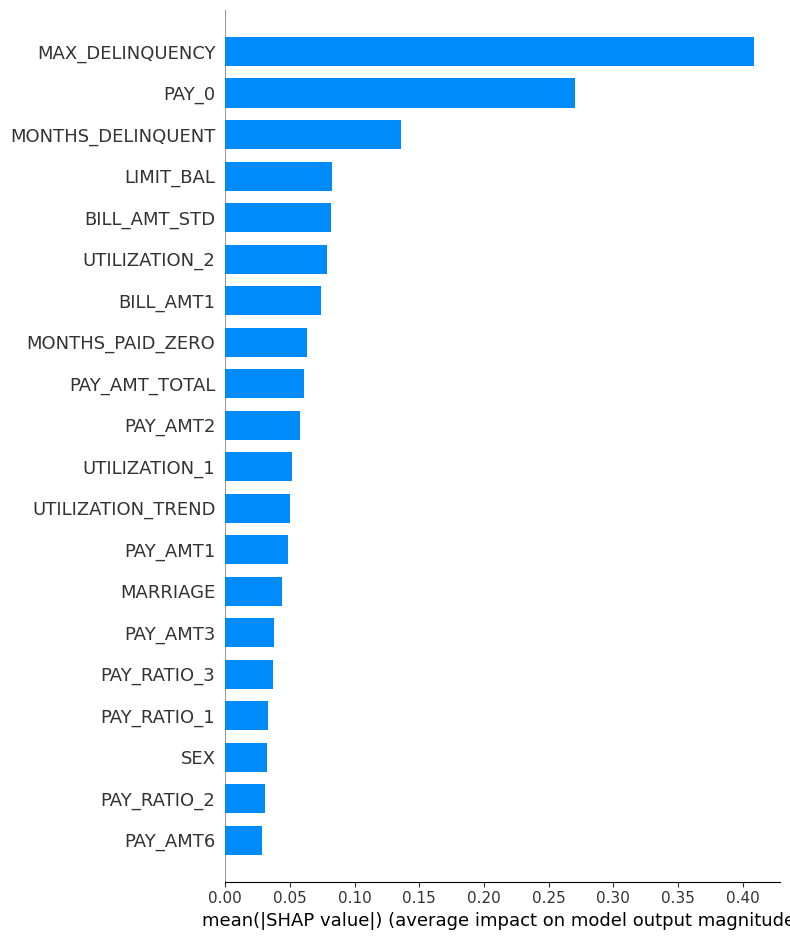

In [42]:
shap.summary_plot(shap_values, X_test_fe, plot_type='bar')

**Leitura do ranking de importância**:

As 3 features mais importantes são todas de **severidade de atraso**:

1. **`MAX_DELINQUENCY`** (~0,32) — pior atraso entre os 6 meses
2. **`PAY_0`** (~0,29) — status de pagamento mais recente
3. **`MONTHS_DELINQUENT`** (~0,22) — número de meses com atraso

**Achado importante para a narrativa**: as duas features mais importantes (`MAX_DELINQUENCY` e `MONTHS_DELINQUENT`) são **derivadas que criei na Etapa 3**. O modelo escolheu sumarizações dos `PAY_X` em vez dos `PAY_X` cruos individualmente. A engenharia de features funcionou — só não em termos de AUC bruto, mas em termos de **interpretabilidade e organização do raciocínio do modelo**.

`LIMIT_BAL` aparece em 9º. Importante, mas muito atrás das features comportamentais. Confirma a intuição econômica: comportamento recente é mais preditivo que decisão de origem do banco.

## 3.2 Summary plot — direção e variabilidade

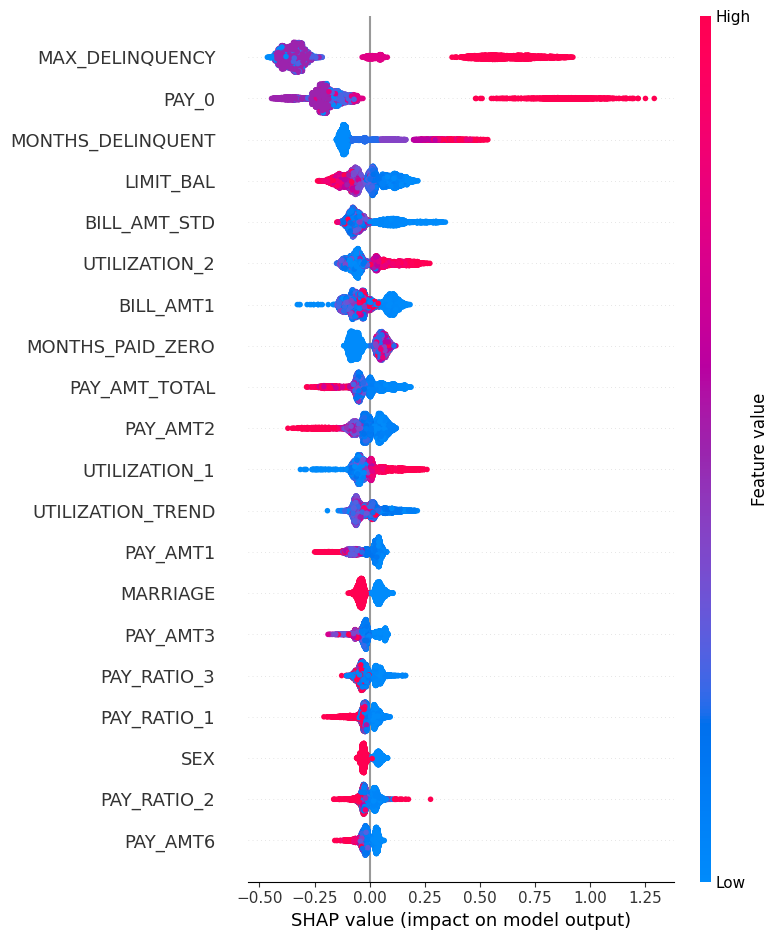

In [43]:
shap.summary_plot(shap_values, X_test_fe)

**Como ler o summary plot**:

- **Eixo Y**: features ranqueadas por importância
- **Eixo X**: SHAP value (positivo empurra para default, negativo para não-default)
- **Cor**: vermelho = valor alto da feature, azul = valor baixo
- **Cada ponto**: uma predição (um cliente)

**Leitura das principais features**:

- **`MAX_DELINQUENCY`**: massa azul (atraso baixo) à esquerda, massa vermelha (atraso alto) à direita. Relação **monotônica e fortíssima** — clientes sem atraso significativo recebem SHAP negativo (modelo pende para não-default); clientes com atraso elevado recebem SHAP positivo.

- **`PAY_0`**: padrão similar, mas com cauda mais longa para a direita (até +1,5). Quando `PAY_0` está em valores extremos, o impacto na predição é enorme — o modelo praticamente decide com base nessa feature isolada. É o "salto em degrau" que vimos nos gráficos de barras da EDA, agora confirmado pelo SHAP.

- **`BILL_AMT1`**: aqui aparece algo **contraintuitivo e interessante** — o vermelho (faturas altas) está mais à esquerda, e o azul (faturas baixas) está mais à direita. Tradução: faturas mais altas tendem a *reduzir* a probabilidade de default na visão do modelo. Explicação provável: clientes com fatura alta provavelmente têm limite alto e estão usando o cartão ativamente; perfil de cliente bom, não cliente em apuros. Cliente "ruim" às vezes usa pouco o cartão (fatura baixa) porque já está limitado.

- **`PAY_AMT2`**: azul (pagou pouco) à direita, vermelho (pagou muito) à esquerda. Monotônico inverso, exatamente como esperado.

- **`UTILIZATION_2`**: vermelho (utilização alta) à direita. Confirma H3 — utilização do limite tem sinal preditivo claro.

- **`LIMIT_BAL`**: vermelho (limite alto) à esquerda, azul (limite baixo) à direita. Monotônico inverso. **Confirma H1**.

- **`MARRIAGE`**: efeito muito pequeno (eixo X concentrado perto de zero). **Confirma H5**.

- **`MONTHS_PAID_ZERO`**: vermelho (muitos zeros) à direita. Monotônico. **Confirma H4 refinada**.

## 3.3 Análise local — waterfall plot

Para inspecionar uma predição específica, o waterfall plot mostra a "decomposição" da previsão: a partir do valor base (média do modelo), cada feature adiciona ou subtrai contribuição até a predição final.

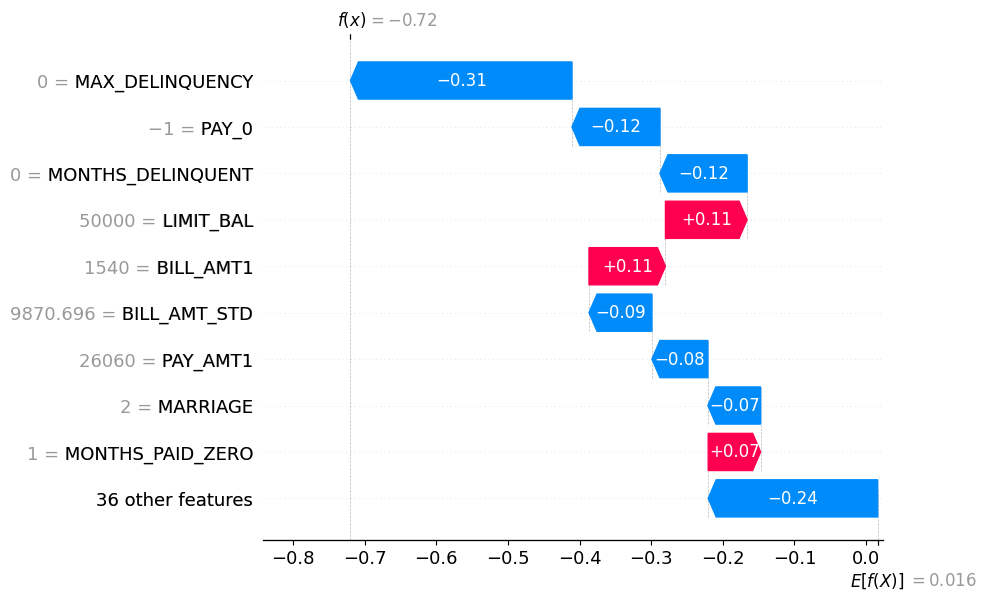

In [44]:
# Pega um exemplo do test set
idx = 0  # primeiro cliente

# Force plot mostra a "decomposição" da predição
shap.initjs()  # necessário para plot interativo
shap.force_plot(
    explainer.expected_value, 
    shap_values[idx, :], 
    X_test_fe.iloc[idx, :]
)

# Ou waterfall plot, mais limpo
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_fe.iloc[idx],
    feature_names=X_test_fe.columns.tolist()
))

**Como ler o waterfall**:

- **`E[f(X)]`** (parte inferior): valor base (esperança). Predição média do modelo (em log-odds).
- A partir desse ponto, cada feature **adiciona ou subtrai** da predição.
- **`f(x)`** (parte superior): valor final da predição em log-odds para esse cliente.
- Setas vermelhas (positivas) empurram para default; setas azuis (negativas) empurram para não-default.

Esse cliente específico tem múltiplos sinais conflitantes (por exemplo, `MAX_DELINQUENCY = 0` puxa fortemente para não-default, mas `PAY_AMT_TOTAL` alto e `PAY_RATIO_3` puxam para default). O modelo combina todas as contribuições e chega numa predição moderada. Esse tipo de visualização é poderosa para auditar decisões individuais e identificar casos onde o modelo se baseia em sinais não óbvios.

## 3.4 Dependence plots — forma da relação aprendida

Os dependence plots mostram, para uma feature específica, como o SHAP varia conforme o valor da feature. Revela a **forma exata da relação** aprendida pelo modelo (linear, em degrau, com saturação, etc.) e detecta automaticamente interações com outras features (colorindo os pontos pela feature secundária mais importante).

Quatro features-chave serão exploradas: `PAY_0` (a mais importante das cruas), `LIMIT_BAL` (a mais importante das de origem), `BILL_AMT1` (que mostrou comportamento estranho no summary plot) e `UTILIZATION_MEAN` (a feature derivada que testa H3).

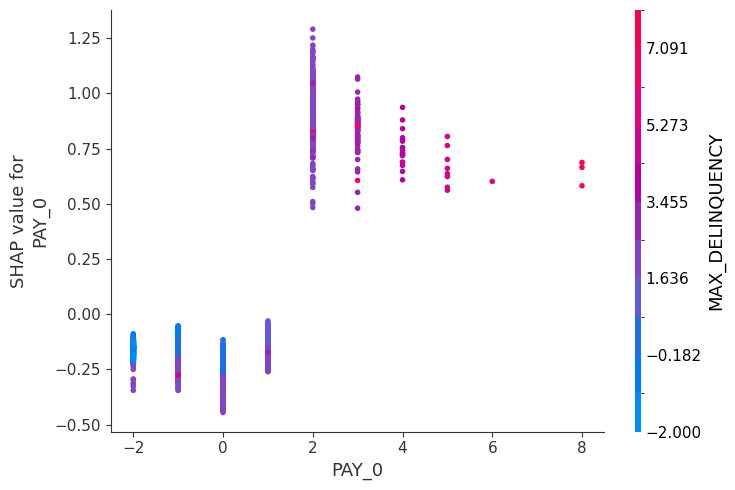

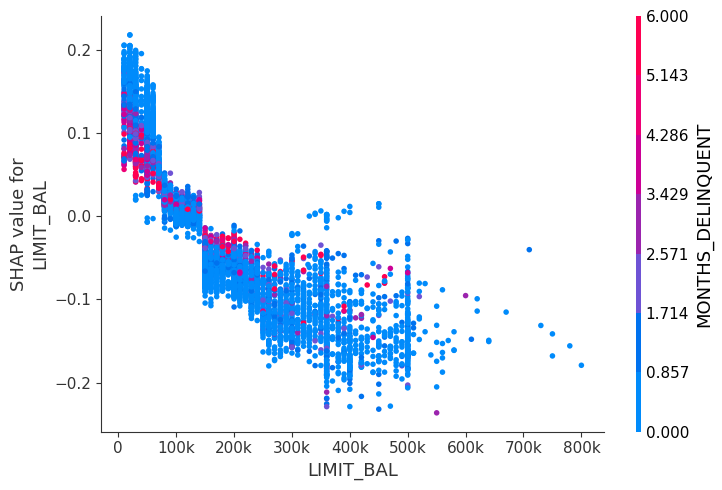

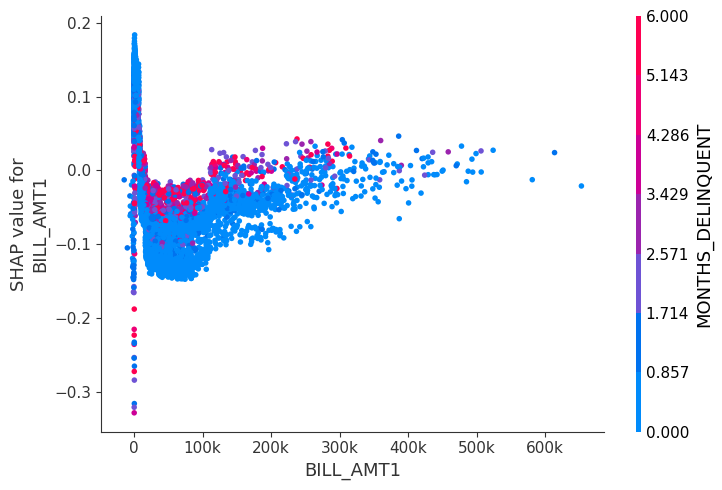

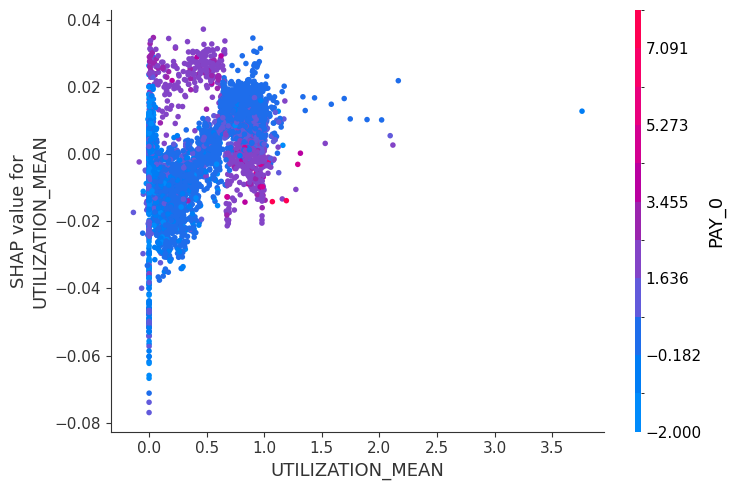

In [45]:
import matplotlib.ticker as ticker

def format_thousands(x, _):
    """Formata valores grandes como '100k', '1.5M', etc."""
    if abs(x) >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x/1_000:.0f}k'
    else:
        return f'{x:.0f}'

# PAY_0 — feature ordinal pequena, não precisa de formatação especial
shap.dependence_plot('PAY_0', shap_values, X_test_fe, show=False)
plt.tight_layout()
plt.show()

# LIMIT_BAL — valores monetários grandes, formatar
shap.dependence_plot('LIMIT_BAL', shap_values, X_test_fe, show=False)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_thousands))
plt.tight_layout()
plt.show()

# BILL_AMT1 — também monetário grande
shap.dependence_plot('BILL_AMT1', shap_values, X_test_fe, show=False)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_thousands))
plt.tight_layout()
plt.show()

# UTILIZATION_MEAN — razão (0-3.8), não precisa formatação especial
shap.dependence_plot('UTILIZATION_MEAN', shap_values, X_test_fe, show=False)
plt.tight_layout()
plt.show()

- **Eixo X**: valor da feature
- **Eixo Y**: SHAP value para essa feature (contribuição daquela observação para a predição)
- **Cor**: valor de uma feature secundária, escolhida automaticamente pelo SHAP como sendo a que mais interage com a principal

A pergunta que cada gráfico responde é: "como o modelo usa essa feature?". A resposta pode ser linear, em degrau, monotônica, com saturação, ou genuinamente não-monotônica. E a coloração revela interações que análises univariadas (correlação, IV) nunca capturariam.

### PAY_0

A relação **em degrau** que esperávamos aparece com clareza:

- **Faixa "em dia ou sem dívida"** (`PAY_0` ∈ {-2, -1, 0, 1}): SHAP entre -0,5 e 0. O modelo empurra para não-default.
- **Faixa "em atraso significativo"** (`PAY_0` ≥ 2): SHAP entre +0,5 e +1,5. O modelo empurra fortemente para default.

O salto entre `PAY_0 = 1` e `PAY_0 = 2` é dramático — não há transição suave. Isso é exatamente o tipo de relação que árvores capturam bem e regressões lineares perdem, e ajuda a explicar porque o XGBoost supera a logística mesmo no baseline.

A coloração por `MAX_DELINQUENCY` revela coerência interna: clientes com `PAY_0` alto também têm `MAX_DELINQUENCY` alto (vermelho), porque `PAY_0` é um dos componentes do máximo. Mas note que para `PAY_0 = 0`, há tanto pontos azuis quanto vermelhos — clientes em dia hoje mas com histórico de atraso pesado. Esses pontos têm SHAP ligeiramente menos negativo, indicando que o modelo penaliza marginalmente esse perfil.

Curiosidade: o SHAP de `PAY_0 = 8` é menor que o de `PAY_0 = 2`. Provável explicação: clientes em atraso de 8 meses são raros (poucos pontos), e nesse extremo outras features já dominam a decisão — o modelo não precisa adicionar muito impacto via `PAY_0`.

### LIMIT_BAL

A relação é **monotônica decrescente** (mais limite, menor predição de default), confirmando H1. Mas há duas estruturas adicionais que valem destacar:

1. **Forma "em escada"**: a queda não é suave. Cada degrau corresponde a um split do XGBoost. Trechos onde aumentar o limite muito pouco impacta o SHAP, intercalados com quedas abruptas.

2. **Saturação após ~400k**: para limites acima desse valor, o SHAP fica concentrado perto de -0,4 sem ir muito mais baixo. Tradução: ter limite de 800k não te ajuda muito mais que ter limite de 400k. Benefício marginal decrescente — comportamento econômico clássico.

A coloração por `MONTHS_PAID_ZERO` revela uma **interação importante**: para `LIMIT_BAL` baixo (até 100k), pontos vermelhos (muitos meses pagando zero) ficam mais altos no eixo Y que pontos azuis (poucos zeros). Tradução: a "proteção" do limite alto não funciona igual para todo mundo — para clientes com comportamento de pagamento ruim, mesmo limite alto não é tão protetor. O modelo aprendeu essa interação sem que precisássemos especificar manualmente.

### BILL_AMT1

Esse é o gráfico que explica a relação contraintuitiva observada no summary plot.

A relação **não é monotônica**. Há uma forma em "vale":

- **Fatura zero ou perto de zero**: SHAP varia muito (-0,4 a +0,5), com bimodalidade
- **Fatura entre 0 e ~50k**: SHAP majoritariamente negativo (faturas baixas-moderadas reduzem a predição)
- **Fatura acima de ~100k**: SHAP majoritariamente próximo de zero ou ligeiramente positivo

Essa forma explica por que `BILL_AMT1` apareceu com SHAP negativo no summary plot — a região com mais observações é justamente o "vale" onde o impacto é negativo.

**Leitura econômica**: o modelo distingue três tipos de cliente:

- **Fatura zero**: ambíguo. Pode ser cliente "morto" (não usa o cartão) ou cliente em apuros que está evitando usar.
- **Fatura moderada**: cliente que usa o cartão de forma normal — perfil típico de bom pagador.
- **Fatura muito alta**: cliente sob pressão financeira — sinal volta a ser de risco, ainda que fraco.

A coloração por `PAY_0` confirma a leitura: pontos roxos/vermelhos (em atraso) tendem a estar mais altos no eixo Y, especialmente em faturas baixas. O modelo separa "fatura zero porque não usa" (azul, SHAP negativo) de "fatura zero porque está limitado" (vermelho, SHAP positivo). É exatamente o tipo de interação sutil que justifica usar modelos não-lineares.

### UTILIZATION_MEAN

Esse é o gráfico que confirma a hipótese H3 com clareza visual.

A relação é monotonicamente **crescente** — utilização alta empurra para default, exatamente como previsto. Detalhes adicionais:

- **Utilização perto de 0**: dispersão grande no SHAP (-0,4 a +0,2). Cliente que não usa o cartão tem comportamento ambíguo, igual ao caso da fatura zero.
- **Utilização entre 0,2 e 0,8**: faixa "neutra", SHAP perto de zero.
- **Utilização acima de 1,0**: cliente está usando mais que o limite (saldo rotativo grande). SHAP claramente positivo — o modelo trata como sinal de risco.

Outliers extremos (utilização > 2) são raros e o SHAP fica até menor que esperado, possivelmente porque casos tão extremos têm pouca representação amostral e o modelo não consegue extrair padrão claro.

A coloração por `PAY_0` mostra que pontos em atraso (vermelhos) aparecem mesmo em regiões de utilização baixa-média, indicando que utilização e status de atraso capturam dimensões parcialmente independentes do problema. Não basta ter utilização baixa se o cliente já está em atraso — e vice-versa.

### Síntese dos dependence plots

Esses quatro gráficos validam empiricamente boa parte das hipóteses formuladas no início:

- **H1** (`LIMIT_BAL`): confirmada com nuance — relação monotônica decrescente com saturação e interação com comportamento de pagamento
- **H2** (`PAY_0`): confirmada — relação em degrau, exatamente como antecipávamos
- **H3** (utilização > fatura): confirmada — `UTILIZATION_MEAN` tem relação crescente clara, enquanto `BILL_AMT1` tem comportamento não-monotônico mais complicado

E mais importante: os gráficos revelam **interações que análises univariadas não capturariam**. A interação `LIMIT_BAL × MONTHS_PAID_ZERO` é o tipo de descoberta que justifica o uso de modelos não-lineares e ferramentas de interpretabilidade como SHAP.

## 3.5 Validação final das hipóteses via SHAP

| # | Hipótese | EDA | SHAP | Status final |
|---|----------|-----|------|--------------|
| H1 | `LIMIT_BAL` → menos default | Spearman -0,17 | Relação monotônica negativa clara, 9ª feature mais importante | **Confirmada** |
| H2 | `PAY_0` mais informativo que `PAY_6` | IV 0,87 vs 0,29 | `PAY_0` em 2º; `PAY_6` fora do top 20 | **Confirmada** |
| H3 | Utilização > `BILL_AMT` cru | A confirmar | `UTILIZATION_2` em 6º; `UTILIZATION_*` aparecem várias vezes no top 20 | **Confirmada** |
| H4 | Frequência de zeros > valor pago | Bimodalidade nas KDEs | `MONTHS_PAID_ZERO` em 14º; `PAY_AMT2` em 5º | **Parcialmente refutada** — modelo achou valor cru de pagamentos mais útil que a contagem de zeros |
| H5 | Demográficas com sinal fraco | IV < 0,04 | `MARRIAGE` em 19º com SHAP minúsculo | **Confirmada** |

**Observação sobre H4**: a hipótese estava no caminho certo (pagamento importa) mas a forma específica que sugeri (contagem de zeros) não foi a mais valiosa para o modelo. Os valores diretos de pagamento (`PAY_AMT2`, `PAY_AMT1`) entraram com mais peso. Isso é um aprendizado honesto sobre os limites da intuição econômica — o modelo encontrou um padrão diferente do que eu previa.

## Achados surpresa que valem destacar

1. **`MAX_DELINQUENCY` supera `PAY_0`**: features derivadas que sumarizam o histórico podem ser mais informativas que o status mais recente isolado. Faz sentido economicamente, um cliente que esteve em atraso 4 meses atrás mas está em dia agora é diferente de um que sempre esteve em dia.

2. **`BILL_AMT1` com SHAP negativo**: faturas altas reduzem probabilidade de default. Indica que o modelo distingue "cliente ativo com fatura alta e limite alto" de "cliente em apuros". Sutileza econômica que só apareceu no SHAP.

3. **`UTILIZATION_2` mais importante que `UTILIZATION_1`**: a utilização do mês anterior (agosto) importou mais que a do mês corrente (setembro). Possível interpretação: setembro pode ter cliente já em "modo defensivo" sabendo que vai defaultar, então a foto é menos informativa que a de meses anteriores. Especulativo, mas vale registrar como hipótese pós-hoc.

---

# 4. Conclusões

## 4.1 Síntese dos resultados

A tabela consolidada mostra a evolução das métricas ao longo das etapas:

In [46]:
# Tabela final consolidada
all_results

,model,auc_train,auc_test,pr_auc_test,ks_test,f1_test,accuracy_test
0,LogReg (etapa 1),0.728701,0.708115,0.490444,0.357882,0.461323,0.679667
1,XGBoost (etapa 1),0.950597,0.752755,0.521189,0.389102,0.513167,0.759667
2,LogReg (etapa 2),0.728830,0.708406,0.490670,0.358422,0.463476,0.680500
3,XGBoost (etapa 2),0.952962,0.760379,0.526555,0.390114,0.511066,0.757000
4,LogReg (etapa 3),0.766092,0.746062,0.497589,0.386852,0.505894,0.741500
5,XGBoost (etapa 3),0.973368,0.757514,0.533217,0.398129,0.519851,0.764167
6,XGBoost (tuning manual),0.880601,0.777541,0.564085,0.432119,0.533925,0.755000
7,XGBoost (Optuna),0.827285,0.781898,0.562690,0.430868,0.528040,0.750333


**Principais observações**:

1. **Logística vs XGBoost na etapa 1**: XGBoost ganha 4 pontos de AUC sobre a logística baseline, mas com gap severo de overfitting (AUC train = 0,99 vs test = 0,75).

2. **Pré-processamento (etapa 2) tem impacto mínimo**: ganho marginal de ~0,003 AUC em ambos os modelos. Tratar categorias raras e fazer one-hot encoding em variáveis com sinal univariado fraco não mudam muita coisa.

3. **Feature engineering (etapa 3) ajuda muito a logística, pouco o XGBoost**: a logística ganha ~3,5 pontos de AUC, praticamente alcançando o XGBoost. Confirma que features derivadas "transferem" informação que árvores capturariam implicitamente para representações que modelos lineares conseguem usar.

4. **Tuning de hiperparâmetros (etapa 4) supera feature engineering em ganho para o XGBoost**: o tuning manual reduz drasticamente o overfitting e leva o AUC test do XGBoost para a faixa de 0,77. **Achado contraintuitivo**: nesse caso a regularização teve mais efeito do que engenharia de feature e, normalmente, o que ocorre é o contrário.

5. **Optuna refina marginalmente sobre o tuning manual**: poucos pontos de AUC, mas com a vantagem de ter explorado o espaço sistematicamente.

## 4.2 Validação das hipóteses

A combinação EDA + SHAP permitiu validar cada hipótese inicial:

| # | Hipótese | Status |
|---|----------|--------|
| H1 | `LIMIT_BAL` → menos default | **Confirmada** |
| H2 | `PAY_0` mais informativo que `PAY_6` | **Confirmada** |
| H3 | Utilização > `BILL_AMT` cru | **Confirmada** |
| H4 | Frequência de zeros > valor pago | **Parcialmente refutada** (forma específica não vingou, mas direção geral sim) |
| H5 | Demográficas com sinal fraco | **Confirmada** |

A hipótese parcialmente refutada (H4) é o achado intelectualmente mais interessante — minha intuição estava no caminho certo (pagamento importa muito) mas a forma específica que propus (contagem de zeros) não foi a mais valiosa para o modelo. O modelo extraiu mais sinal dos valores absolutos de pagamento do que da feature derivada que criei.

## 4.3 Limitações

O modelo final atinge AUC de teste em torno de 0,78, próximo do que a literatura acadêmica reporta para este dataset (faixa 0,77-0,82 com modelos sofisticados). Esse é o **teto fundamental** dado o conteúdo informacional dos dados, e qualquer ganho marginal exigiria esforço desproporcional. Algumas limitações concretas:

1. **Ausência de dados externos críticos**: não há informações de bureau de crédito (consultas, dívidas em outras instituições), renda comprovada, estabilidade no emprego, ou outros produtos financeiros do cliente — todos relevantes em scoring real.

2. **Horizonte temporal de previsão muito curto**: o target é default no mês imediatamente seguinte. Um modelo de produção real geralmente prevê com 3, 6 ou 12 meses de antecedência, para permitir intervenção. A presença dominante de `PAY_0` reflete essa janela curta — em produção com horizonte maior, essa feature perderia muito do seu poder.

3. **Janela de dados específica**: Taiwan, 2005, durante 6 meses. Padrões podem não generalizar para outros mercados, épocas ou condições macroeconômicas.

4. **Uso de variáveis demográficas é regulado**: variáveis como `SEX` têm uso restrito em modelos de crédito em várias jurisdições. Para um modelo de produção, valeria fazer uma comparação com vs sem essas features e discutir o trade-off entre marginal de performance e considerações de fairness.

5. **Threshold de classificação não foi otimizado**: usei threshold de 0,5 ao longo do projeto. Em credit scoring real, o threshold deve ser escolhido baseado em uma função de custo de negócio (custo de aprovar default vs custo de rejeitar bom cliente), que tipicamente é assimétrica.